# 1. Data Preparation


### Enviroment

In [1]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score


from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.preprocessing import LabelEncoder

from mpl_toolkits.mplot3d import Axes3D

from sklearn.manifold import TSNE

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import umap

from sklearn.feature_selection import VarianceThreshold
import pandas as pd

from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import SelectKBest, f_classif


from sklearn.svm import SVC

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

### Data Loading (ACDC features + labels)

In [2]:
df = pd.read_csv("/content/drive/MyDrive/ML/ACDC_radiomics.csv")

df.head()

,original_shape_Elongation_LV_ED,original_shape_Flatness_LV_ED,original_shape_LeastAxisLength_LV_ED,original_shape_MajorAxisLength_LV_ED,original_shape_Maximum2DDiameterColumn_LV_ED,original_shape_Maximum2DDiameterRow_LV_ED,original_shape_Maximum2DDiameterSlice_LV_ED,original_shape_Maximum3DDiameter_LV_ED,original_shape_MeshVolume_LV_ED,original_shape_MinorAxisLength_LV_ED,...,original_glszm_ZonePercentage_MYO_ES,original_glszm_ZoneVariance_MYO_ES,original_ngtdm_Busyness_MYO_ES,original_ngtdm_Coarseness_MYO_ES,original_ngtdm_Complexity_MYO_ES,original_ngtdm_Contrast_MYO_ES,original_ngtdm_Strength_MYO_ES,height,weight,class
0,0.560917,0.110560,6.592758,59.630582,45.398238,64.776539,64.007812,65.199693,5674.000000,33.447817,...,0.053567,40384.123570,19.552355,0.000993,36.034390,0.010496,0.091329,184,95,DCM
1,0.454960,0.088323,5.730218,64.877933,40.311289,64.140471,61.000000,67.446275,5015.833333,29.516875,...,0.028344,130808.332098,29.225756,0.000722,17.238110,0.006596,0.045024,160,70,DCM
2,0.541682,0.105418,6.711577,63.666027,48.041649,66.843100,59.135438,68.080834,7817.666667,34.486772,...,0.041404,92088.926893,20.732684,0.001106,13.916093,0.004455,0.069372,165,77,DCM
3,0.487949,0.105906,6.726159,63.510529,44.407207,66.370174,66.007575,66.475559,5629.166667,30.989912,...,0.150855,5232.431686,5.158496,0.000848,216.183657,0.025431,0.208797,159,46,DCM
4,0.442150,0.095225,7.186765,75.471150,68.066144,77.472576,50.487622,77.472576,8550.083333,33.369563,...,0.040613,91705.803093,18.086404,0.000710,41.886924,0.005266,0.123346,165,77,DCM


In [3]:
print('El número de muestras del dataset es {}.'.format(df.shape[0]))

El número de muestras del dataset es 100.


### Data Preparation








*   Separate X and y
*   Handle missing values
*   Normalize / Standardize features






In [4]:
#Separate X and Y

y = df['class']
X = df.drop(columns=['class'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 644)
y shape: (100,)


In [5]:
#Handle missing values

missing_values = df.isnull().sum()

# Display columns with missing values
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [6]:
df.isnull().sum()

,0
original_shape_Elongation_LV_ED,0
original_shape_Flatness_LV_ED,0
original_shape_LeastAxisLength_LV_ED,0
original_shape_MajorAxisLength_LV_ED,0
original_shape_Maximum2DDiameterColumn_LV_ED,0
...,...
original_ngtdm_Contrast_MYO_ES,0
original_ngtdm_Strength_MYO_ES,0
height,0
weight,0


After check and prepare the dataset some actions such as normalize and standardize has been applied to apply multiple models and ensure consistency and compatibility across them.
Following Data Characteristics of the dataset:

*   The ACDC dataset contains radiomic features that come from different cardiac structures (myocardium, left ventricle, right ventricle) and different phases of the cardiac cycle (end-diastole, end-systole). These features can have varying ranges depending on the structure and phase, so standardization or normalization might be necessary to ensure that all features contribute equally to the model.

Although the best practices are for ACDC Dataset should be apply the following rules, we have applied normalization as mandatory step of the analysis.

*   Tree-based models (e.g., Random Forest, XGBoost): No normalization needed.
*   SVM, KNN, and neural networks: Normalization or standardization is recommended.







Normalization is used for features have different scales or are required to be within a specific range.
We have applied Min-Max Scaling because is effective when you want your features to be bounded between a specific range (usually [0, 1]), which is useful for algorithms like neural networks and KNN that are sensitive to the scale of the data.

(((NO USADO FINALMENTE MIN-MAX SCALING USAMOS Z-SCORE POR EL TIPO DE MODELOS UTILIZADOS NO EJECUTAR)))

In [10]:
#Normalization (Min-Max Scaling) Code:

# Create the scaler object
scaler = MinMaxScaler()

# Apply normalization (fit and transform the features)
X_normalized = scaler.fit_transform(X)

# Optionally, convert back to DataFrame for easier handling
X_normalized_df = pd.DataFrame(X_normalized, columns=X.columns)

# Display the normalized data
print("Normalized Features (first 5 rows):")
print(X_normalized_df.head())


Normalized Features (first 5 rows):
   original_shape_Elongation_LV_ED  original_shape_Flatness_LV_ED  \
0                         0.446868                       0.265844   
1                         0.193159                       0.172930   
2                         0.400811                       0.244360   
3                         0.272149                       0.246398   
4                         0.162485                       0.201770   

   original_shape_LeastAxisLength_LV_ED  original_shape_MajorAxisLength_LV_ED  \
0                              0.250608                              0.203943   
1                              0.183639                              0.262023   
2                              0.259834                              0.248610   
3                              0.260966                              0.246888   
4                              0.296729                              0.379274   

   original_shape_Maximum2DDiameterColumn_LV_ED  \
0          

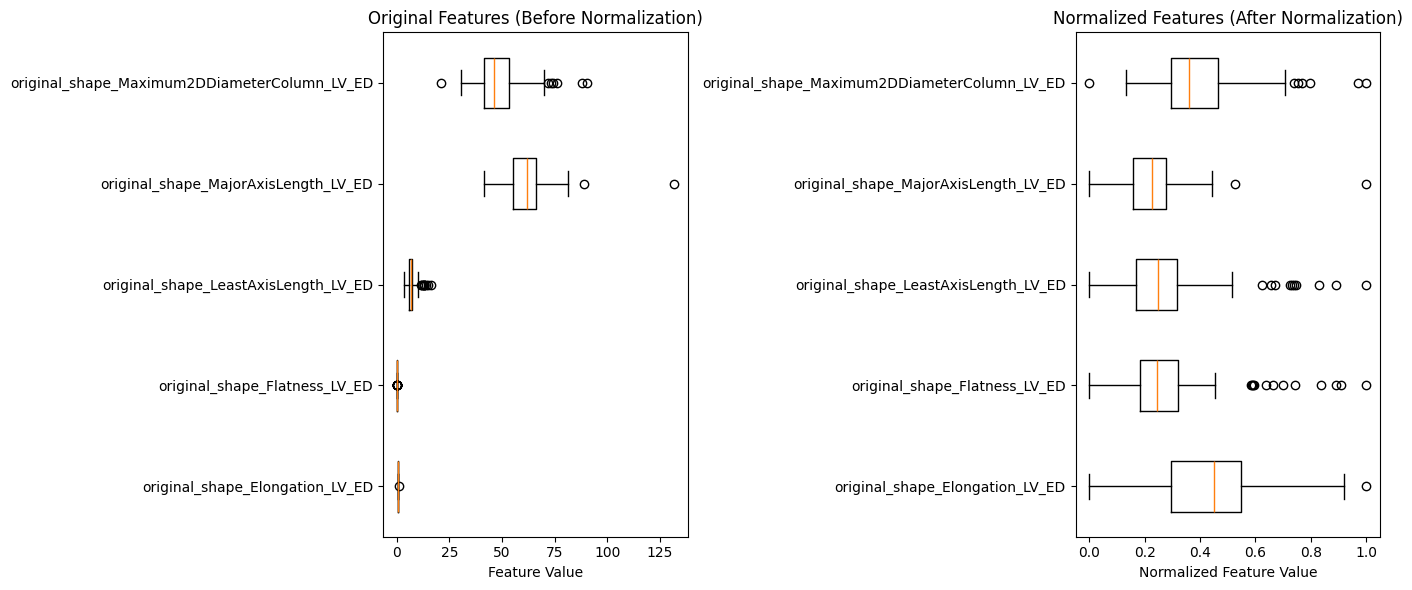

In [22]:
#Plot Plot Normalized vs Original Features:

# Select a few sample features for visualization
sample_features = X.columns[:5]

# Plot before and after normalization
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot original features
ax[0].boxplot(X[sample_features], vert=False)
ax[0].set_title("Original Features (Before Normalization)")
ax[0].set_xlabel("Feature Value")
ax[0].set_yticklabels(sample_features)

# Plot normalized features
ax[1].boxplot(X_normalized_df[sample_features], vert=False)
ax[1].set_title("Normalized Features (After Normalization)")
ax[1].set_xlabel("Normalized Feature Value")
ax[1].set_yticklabels(sample_features)

# Show the plots
plt.tight_layout()
plt.show()

We have used:
Boxplot Visualization: We’re using boxplots to show the distribution of selected features before and after normalization.

Before Normalization: The left plot will show the distribution of feature values in their original scale.

After Normalization: The right plot will show the distribution after applying Min-Max Scaling, where the values are constrained between 0 and 1.

Original Features might have a wide range of values

Normalized Features is squeezed into a range from 0 to 1.

Standardization (Z-score Scaling)  is used due to the data is normally distributed or if the model assumes a Gaussian distribution

In [7]:
# Create the scaler object
scaler = StandardScaler()

# Standardize the features (excluding the target variable 'y')
X_standardized = scaler.fit_transform(X)

# Convert back to DataFrame (optional for easier handling)
X_standardized_df = pd.DataFrame(X_standardized, columns=X.columns)

print("Standardized Features:")
print(X_standardized_df.head())

Standardized Features:
   original_shape_Elongation_LV_ED  original_shape_Flatness_LV_ED  \
0                         0.018494                      -0.128944   
1                        -1.215290                      -0.626099   
2                        -0.205479                      -0.243894   
3                        -0.831159                      -0.232990   
4                        -1.364455                      -0.471784   

   original_shape_LeastAxisLength_LV_ED  original_shape_MajorAxisLength_LV_ED  \
0                             -0.180321                             -0.203596   
1                             -0.538244                              0.265521   
2                             -0.131015                              0.157176   
3                             -0.124964                              0.143274   
4                              0.066171                              1.212562   

   original_shape_Maximum2DDiameterColumn_LV_ED  \
0                       

Visualize Raw vs Normalized Data (Histogram & Boxplot):

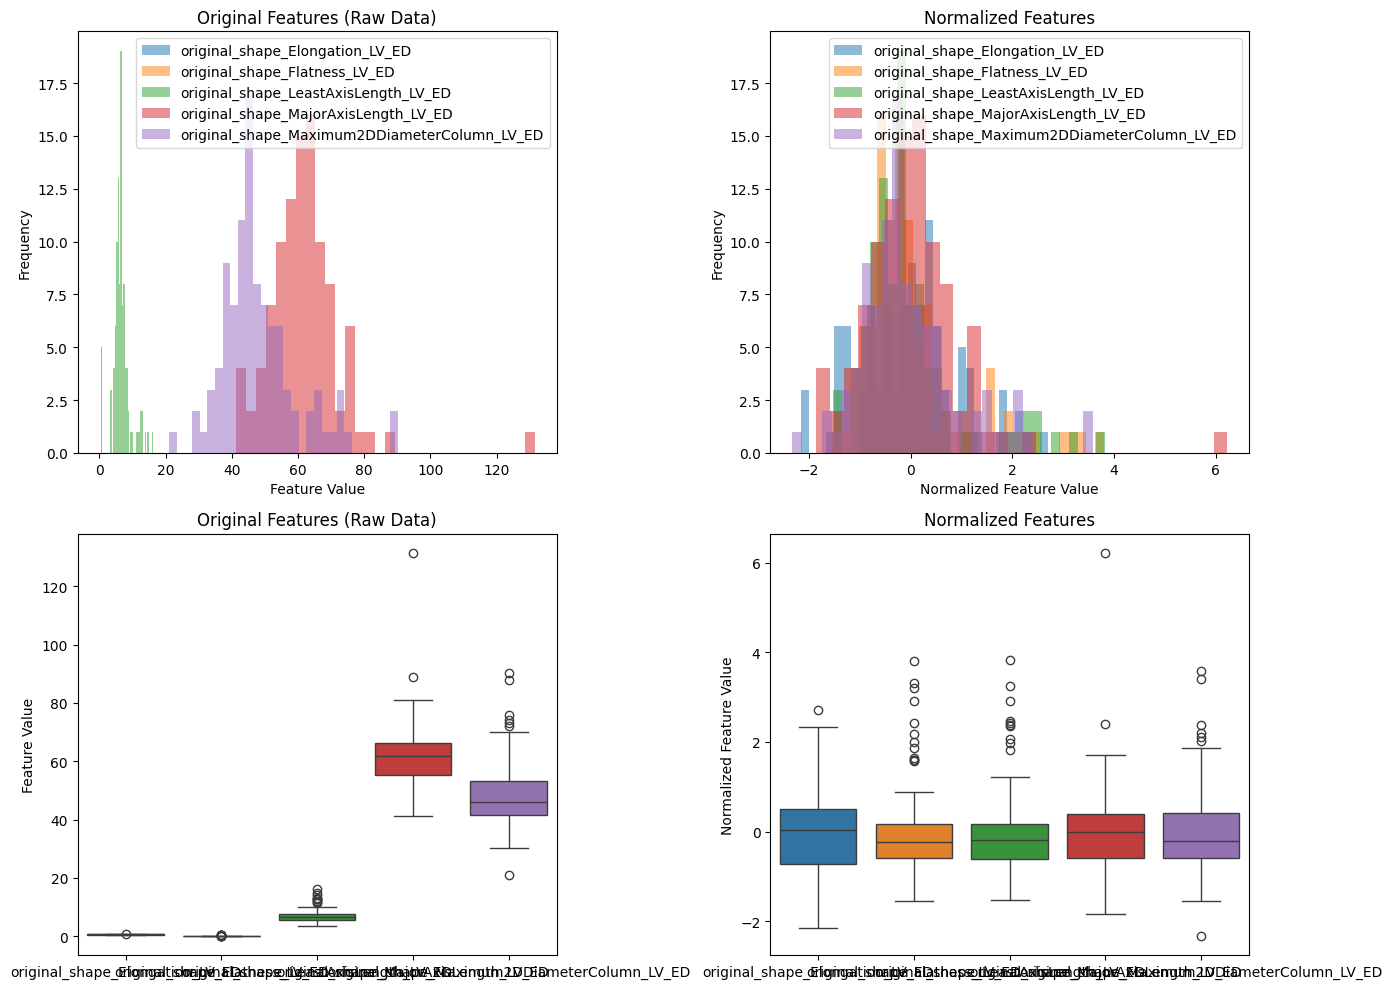

In [8]:
#Select a few sample features for visualization (for comparison)
sample_features = X.columns[:5]  # first 5

# Plot: Raw vs Normalized Data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram: Original Data
for i, feature in enumerate(sample_features):
    axes[0, 0].hist(X[feature], bins=30, alpha=0.5, label=feature)

axes[0, 0].set_title("Original Features (Raw Data)")
axes[0, 0].set_xlabel("Feature Value")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()

# Histogram: Normalized Data
for i, feature in enumerate(sample_features):
    axes[0, 1].hist(X_standardized_df[feature], bins=30, alpha=0.5, label=feature)

axes[0, 1].set_title("Normalized Features")
axes[0, 1].set_xlabel("Normalized Feature Value")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()

# Boxplot: Original Data
sns.boxplot(data=X[sample_features], ax=axes[1, 0])
axes[1, 0].set_title("Original Features (Raw Data)")
axes[1, 0].set_ylabel("Feature Value")

# Boxplot: Normalized Data
sns.boxplot(data=X_standardized_df[sample_features], ax=axes[1, 1])
axes[1, 1].set_title("Normalized Features")
axes[1, 1].set_ylabel("Normalized Feature Value")

# Adjust layout and show
plt.tight_layout()
plt.show()

Histograms:

Left histogram shows the distribution of the original raw features, where can see varying ranges of values.

Right histogram shows the distribution of normalized features which are constrained between 0 and 1.

Boxplots:

The top boxplot shows the raw data's spread, and  must have different scales for different features.

The bottom boxplot shows the normalized data, where all features have the same range (between 0 and 1).

In [11]:
###REVISAR
import pandas as pd
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Separate features and target
features = y
classes = y.value_counts()


# Loop through each feature
for feature in features:
    # Prepare data for ANOVA
    groups = [X_standardized_df[X_standardized_df['class'] == cls][feature] for cls in classes]

    # Apply one-way ANOVA
    anova = f_oneway(*groups)
    print(f"\n🔍 Feature: {feature}")
    print(f"ANOVA F-statistic = {anova.statistic:.4f}, p-value = {anova.pvalue:.4e}")

    # If significant, apply Tukey HSD
    if anova.pvalue < 0.05:
        print("✅ Significant differences found. Running Tukey HSD...")
        tukey = pairwise_tukeyhsd(endog=df[feature], groups=df['class'], alpha=0.05)
        print(tukey.summary())
    else:
        print("❌ No significant difference (ANOVA p >= 0.05). Skipping Tukey HSD.")


# Plotting class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=dfclass, palette='Set2')
plt.title('Figure: Class Distribution of the ACDC Dataset')
plt.xlabel('Cardiac Condition Class')
plt.ylabel('Number of Samples')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()


KeyError: 'class'

# 2. Exploratory Data Analysis (EDA)

In [9]:
X_standardized_df.head()

,original_shape_Elongation_LV_ED,original_shape_Flatness_LV_ED,original_shape_LeastAxisLength_LV_ED,original_shape_MajorAxisLength_LV_ED,original_shape_Maximum2DDiameterColumn_LV_ED,original_shape_Maximum2DDiameterRow_LV_ED,original_shape_Maximum2DDiameterSlice_LV_ED,original_shape_Maximum3DDiameter_LV_ED,original_shape_MeshVolume_LV_ED,original_shape_MinorAxisLength_LV_ED,...,original_glszm_ZoneEntropy_MYO_ES,original_glszm_ZonePercentage_MYO_ES,original_glszm_ZoneVariance_MYO_ES,original_ngtdm_Busyness_MYO_ES,original_ngtdm_Coarseness_MYO_ES,original_ngtdm_Complexity_MYO_ES,original_ngtdm_Contrast_MYO_ES,original_ngtdm_Strength_MYO_ES,height,weight
0,0.018494,-0.128944,-0.180321,-0.203596,-0.251196,-0.250368,0.084002,-0.303286,-0.499934,-0.133662,...,0.861616,0.750089,-0.429108,-0.676039,-0.737801,0.226748,-0.196429,0.443272,1.362036,1.210974
1,-1.215290,-0.626099,-0.538244,0.265521,-0.686820,-0.300399,-0.128500,-0.127869,-0.652512,-0.769670,...,0.549713,-0.070433,-0.207884,-0.402026,-1.118886,-0.081326,-0.599063,-0.126071,-1.121920,-0.299722
2,-0.205479,-0.243894,-0.131015,0.157176,-0.024826,-0.087820,-0.260231,-0.078322,-0.002983,0.034436,...,0.171272,0.354405,-0.302612,-0.642604,-0.578268,-0.135775,-0.820048,0.173303,-0.604429,0.123273
3,-0.831159,-0.232990,-0.124964,0.143274,-0.336063,-0.125018,0.225284,-0.203664,-0.510328,-0.531340,...,2.070360,3.914933,-0.515107,-1.083765,-0.942459,3.179427,1.345261,1.887594,-1.225418,-1.749990
4,-1.364455,-0.471784,0.066171,1.212562,1.689984,0.748258,-0.871197,0.654999,0.166807,-0.146323,...,1.015373,0.328687,-0.303549,-0.717564,-1.136770,0.322672,-0.736347,0.836939,-0.604429,0.123273


### Class Distribution Analysis, we check f the classes are balanced or imbalanced

In [10]:
X_standardized_df.describe()

,original_shape_Elongation_LV_ED,original_shape_Flatness_LV_ED,original_shape_LeastAxisLength_LV_ED,original_shape_MajorAxisLength_LV_ED,original_shape_Maximum2DDiameterColumn_LV_ED,original_shape_Maximum2DDiameterRow_LV_ED,original_shape_Maximum2DDiameterSlice_LV_ED,original_shape_Maximum3DDiameter_LV_ED,original_shape_MeshVolume_LV_ED,original_shape_MinorAxisLength_LV_ED,...,original_glszm_ZoneEntropy_MYO_ES,original_glszm_ZonePercentage_MYO_ES,original_glszm_ZoneVariance_MYO_ES,original_ngtdm_Busyness_MYO_ES,original_ngtdm_Coarseness_MYO_ES,original_ngtdm_Complexity_MYO_ES,original_ngtdm_Contrast_MYO_ES,original_ngtdm_Strength_MYO_ES,height,weight
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,...,1.000000e+02,1.000000e+02,100.000000,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
mean,-1.219025e-15,-3.824718e-16,-8.115730e-16,1.776357e-16,3.286260e-16,1.151301e-15,1.931788e-16,2.692291e-16,-5.107026e-17,8.310019e-16,...,-1.494360e-15,8.132384e-17,0.000000,-1.341982e-16,-5.662137e-16,-1.720846e-17,7.216450e-17,1.232348e-16,-3.264056e-16,3.608225e-16
std,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,...,1.005038e+00,1.005038e+00,1.005038,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00
min,-2.154618e+00,-1.551397e+00,-1.519713e+00,-1.850865e+00,-2.332416e+00,-1.723847e+00,-2.313937e+00,-1.720193e+00,-1.355274e+00,-2.132136e+00,...,-1.659568e+00,-8.873211e-01,-0.527131,-1.179743e+00,-1.512032e+00,-3.546410e-01,-1.151886e+00,-6.378338e-01,-3.191883e+00,-2.414696e+00
25%,-7.284769e-01,-5.806874e-01,-6.142675e-01,-5.875428e-01,-5.932907e-01,-5.798015e-01,-6.179818e-01,-5.878835e-01,-6.093910e-01,-6.562195e-01,...,-7.098970e-01,-5.275722e-01,-0.384219,-6.692513e-01,-7.255387e-01,-3.231307e-01,-5.491452e-01,-5.320317e-01,-6.044292e-01,-7.378237e-01
50%,3.488975e-02,-2.375980e-01,-1.886684e-01,-1.597292e-02,-2.038578e-01,-1.170311e-01,-8.021372e-02,-1.122645e-01,-2.521109e-01,-1.285286e-01,...,-1.959925e-01,-2.782877e-01,-0.210940,-2.399828e-01,-2.044042e-01,-2.948952e-01,-2.506013e-01,-4.047018e-01,6.830878e-02,2.417113e-03
75%,5.103037e-01,1.700461e-01,1.706696e-01,3.970708e-01,4.199379e-01,4.483313e-01,5.073482e-01,4.453812e-01,3.365115e-01,6.187069e-01,...,5.502715e-01,2.976039e-02,0.046034,3.493993e-01,4.251876e-01,-1.386719e-01,1.478796e-01,9.030175e-02,7.410468e-01,6.066954e-01
max,2.708367e+00,3.799317e+00,3.824849e+00,6.226222e+00,3.580187e+00,5.933177e+00,5.382436e+00,5.878530e+00,4.289845e+00,4.104981e+00,...,3.017250e+00,5.694763e+00,8.784744,4.014971e+00,3.672518e+00,8.083119e+00,5.593246e+00,4.857356e+00,2.190021e+00,2.902953e+00


Class distribution:
 class
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64


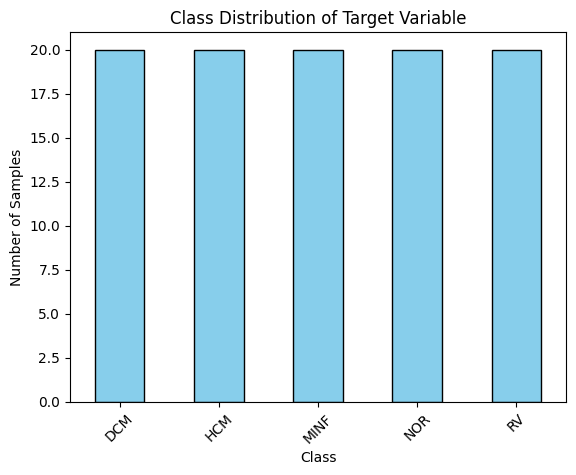

In [11]:
# Class distribution (value counts)
class_counts = y.value_counts()

# Display class counts
print("Class distribution:\n", class_counts)

# Plot a bar chart for class distribution
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution of Target Variable')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()

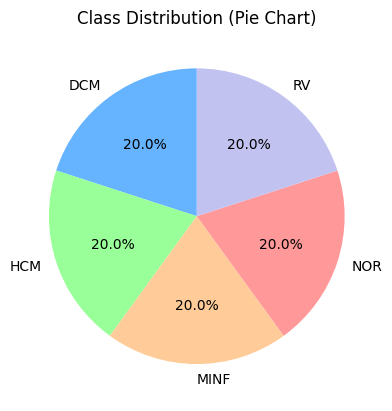

In [12]:
# Visualizing the class distribution with a pie chart
class_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ffcc99','#ff9999','#c2c2f0'], startangle=90, legend=False)
plt.title('Class Distribution (Pie Chart)')
plt.ylabel('')
plt.show()

After checking classes imbalance classes have not been detected

In the following Step applyisualize the feature distribution of your dataset

1. Histogram for Feature Distribution
Show the frequency distribution of each feature, helping you detect skewness or irregular distributions.

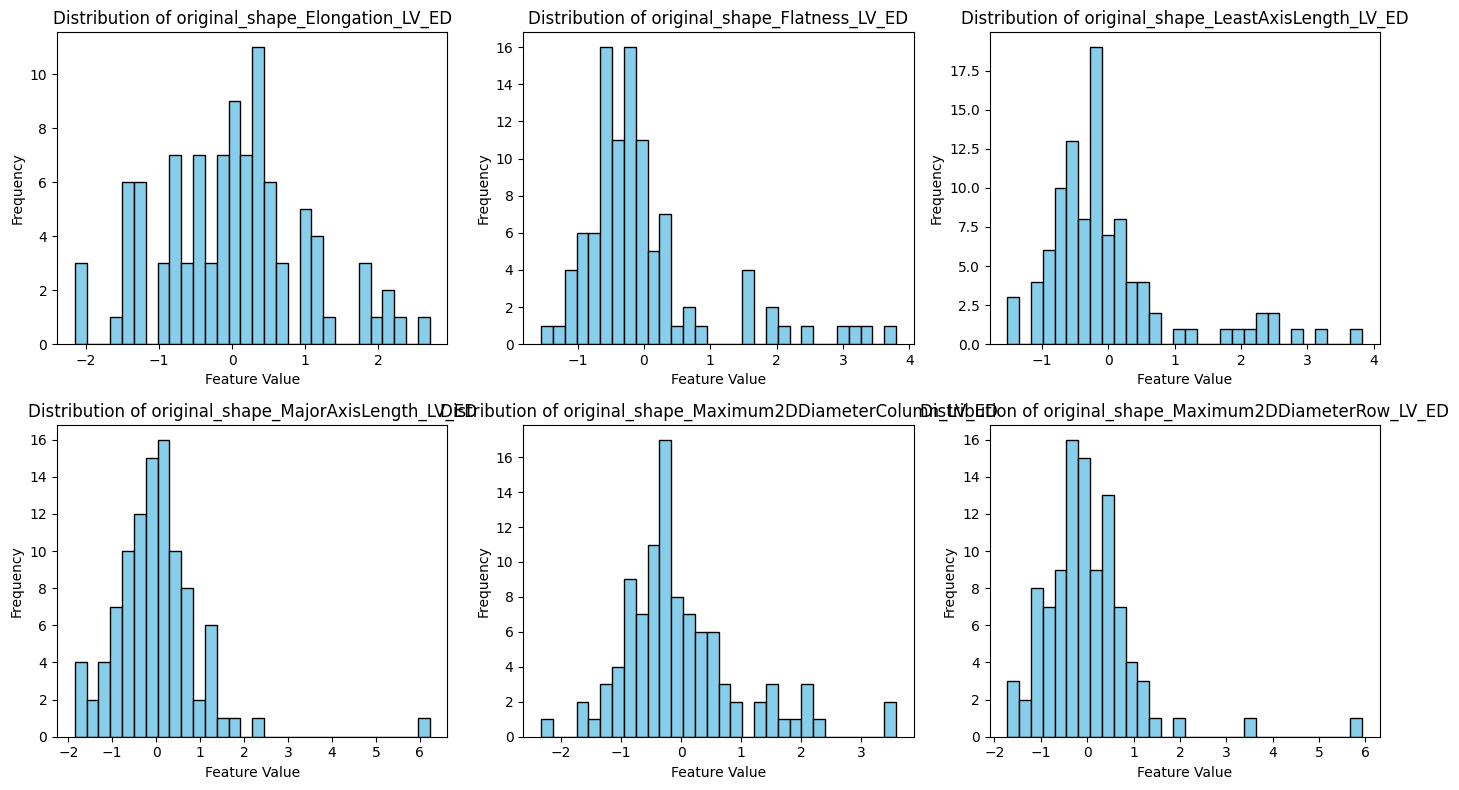

In [13]:
# Visualize the distribution of the first few features
sample_features = X_standardized_df.columns[:6]

# Plot histograms for the selected features
plt.figure(figsize=(14, 8))
for i, feature in enumerate(sample_features):
    plt.subplot(2, 3, i+1)
    plt.hist(X_standardized_df[feature], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {feature}')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

2. Boxplot for Feature Distribution for identifying outliers and visualizing the spread (quartiles) of the features.

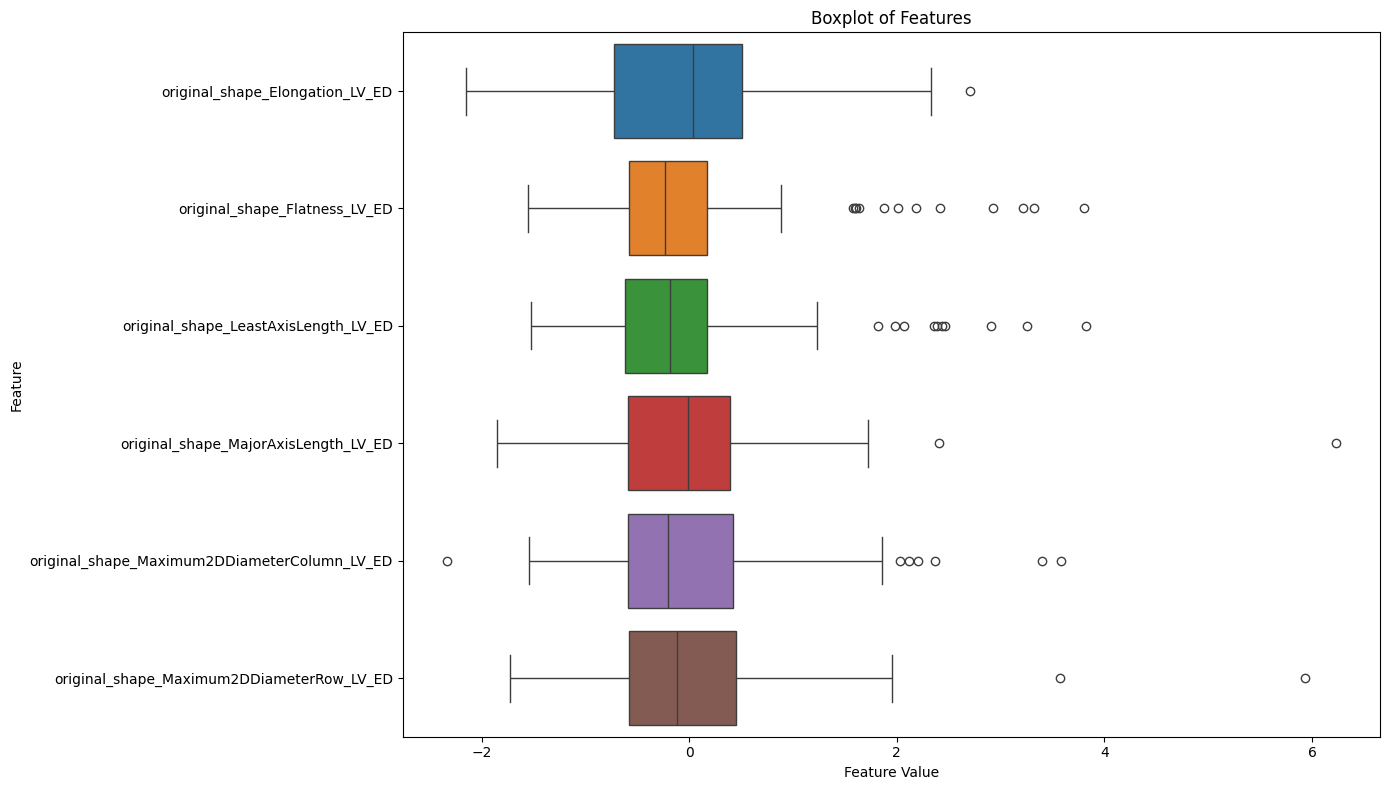

In [14]:
# Boxplot for feature distribution
plt.figure(figsize=(14, 8))
sns.boxplot(data=X_standardized_df[sample_features], orient='h')
plt.title('Boxplot of Features')
plt.xlabel('Feature Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

3. Kernel Density Estimate (KDE) Plot smoothed curve that shows the probability density of the features.




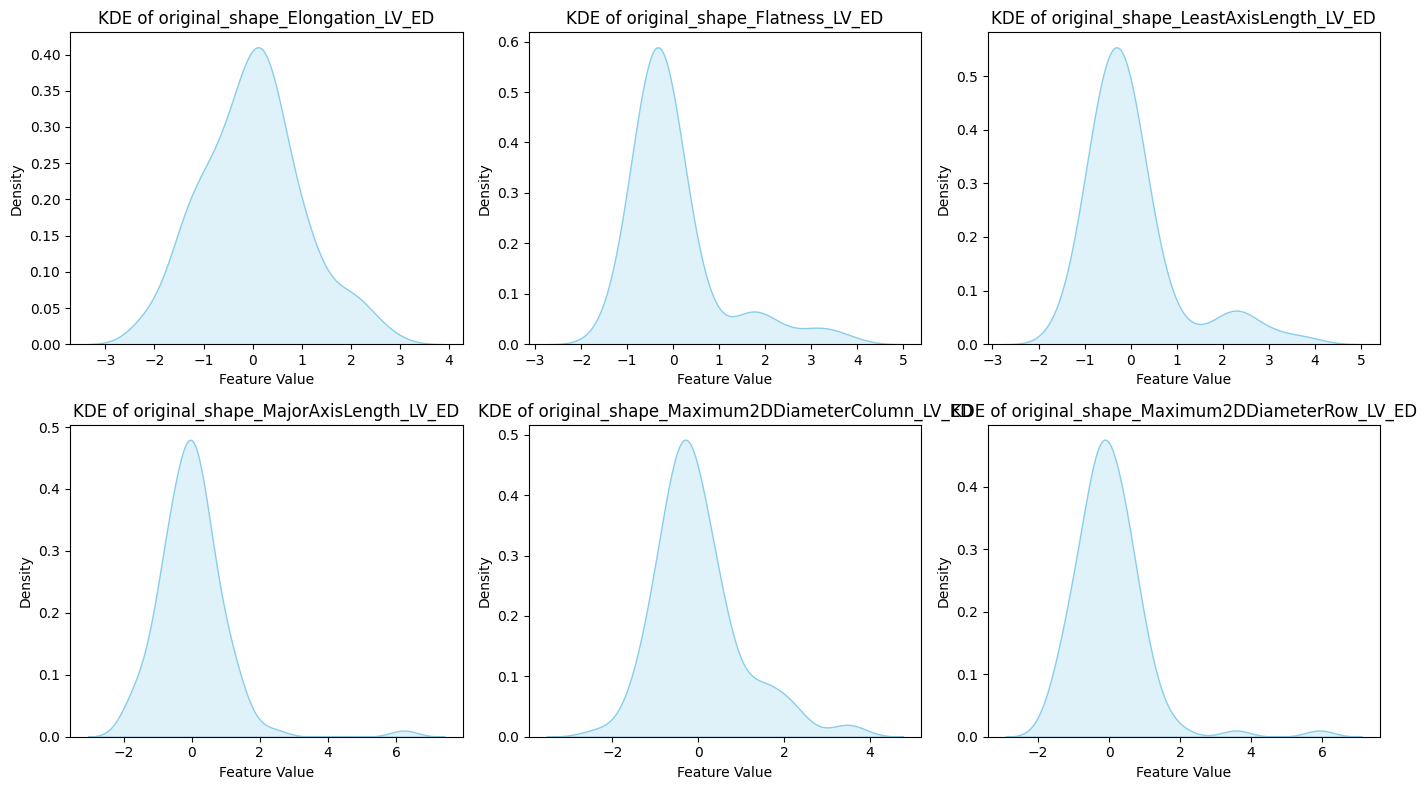

In [15]:
# KDE plot to visualize the smooth distribution of features
plt.figure(figsize=(14, 8))
for i, feature in enumerate(sample_features):
    plt.subplot(2, 3, i+1)
    sns.kdeplot(X_standardized_df[feature], shade=True, color='skyblue')
    plt.title(f'KDE of {feature}')
    plt.xlabel('Feature Value')
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

Pairplot (Pairwise Relationship) o explore how features relate to one another. or seeing relationships between multiple features at once.

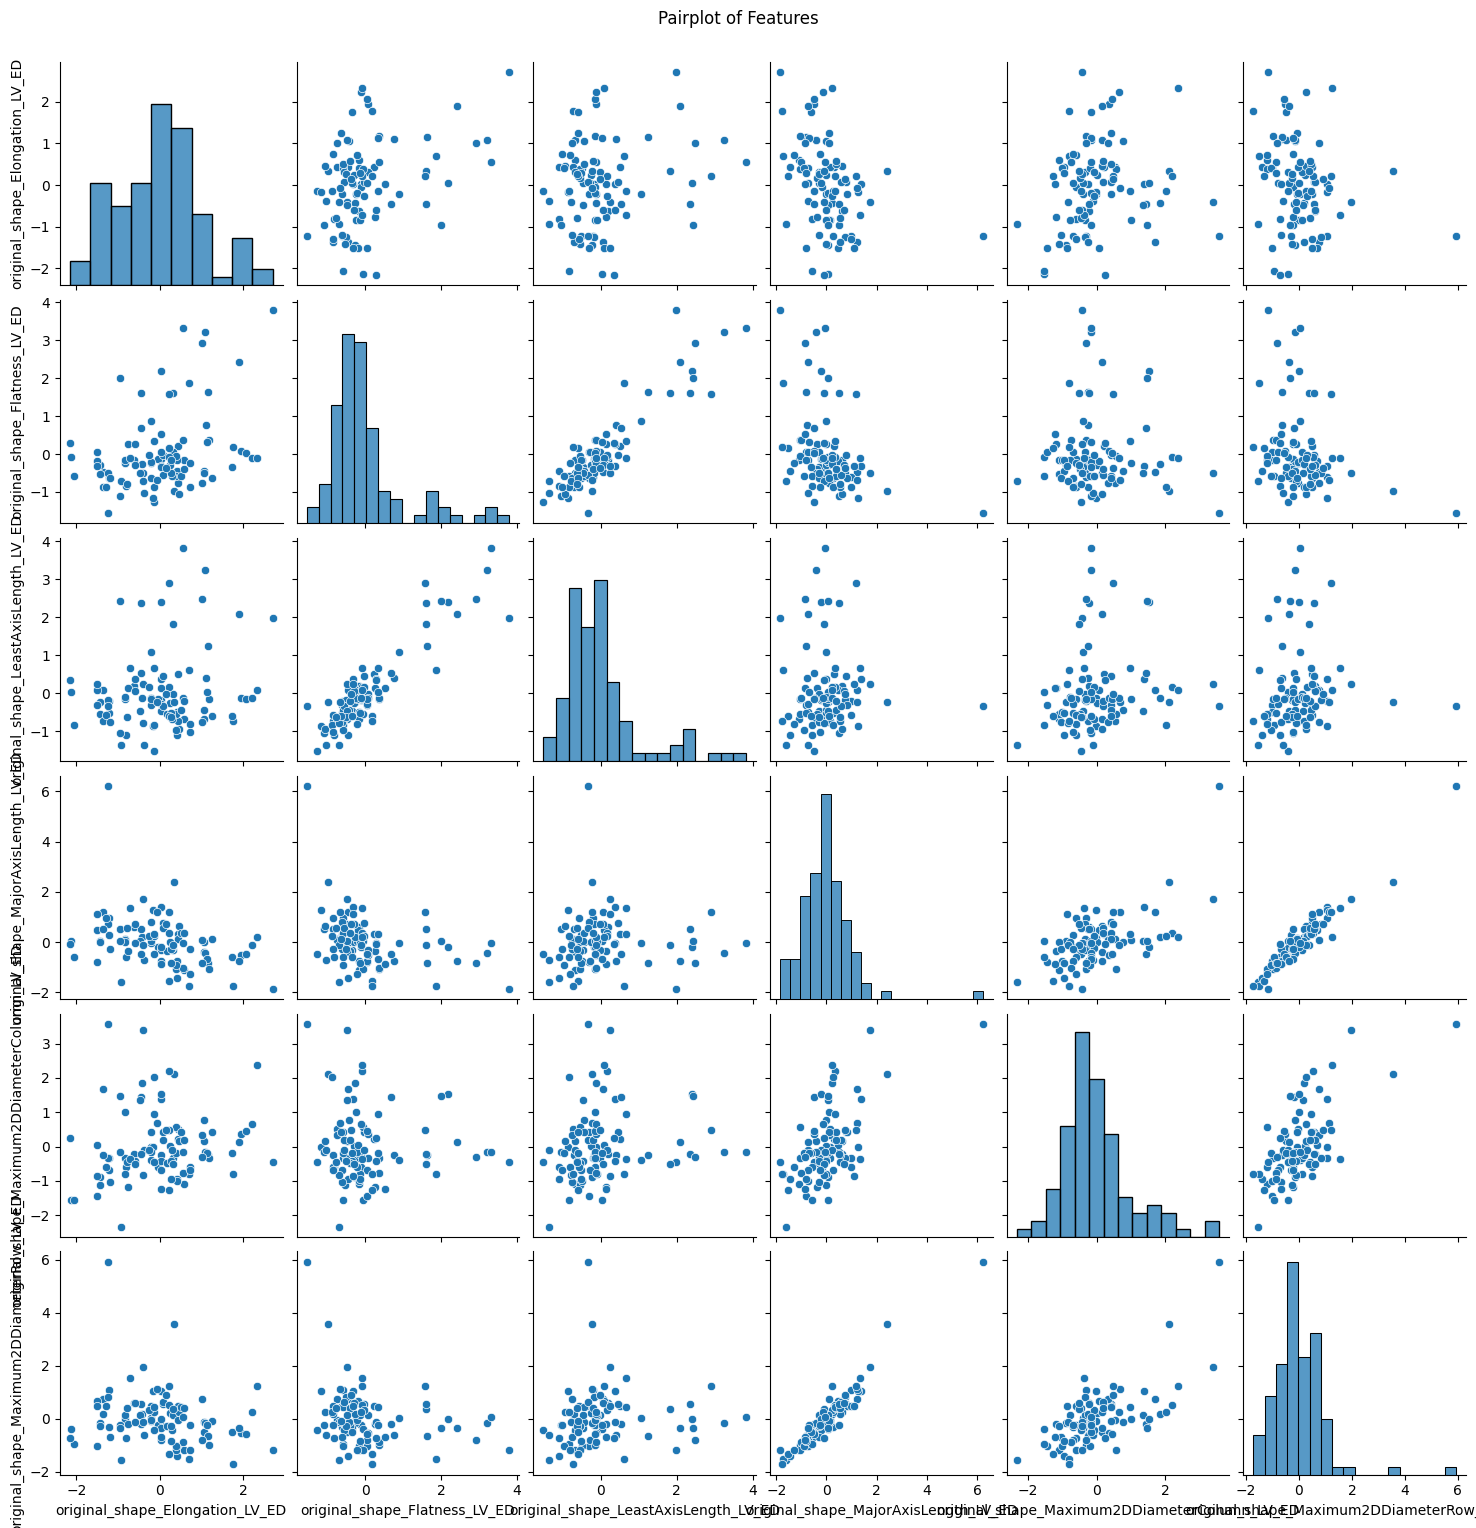

In [16]:
# Pairplot for feature relationships (can be used for a subset of features)
sns.pairplot(X_standardized_df[sample_features])
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()

### Correlation Variables analysis on the dataset and visualize the relationships between different features, to identify how strongly features are related to one another and can be particularly useful for feature selection or understanding multicollinearity.

1. Calculate Pearson Correlation Matrix
earson correlation measures the linear relationship between features. It ranges from -1 to 1:

1: Perfect positive correlation

-1: Perfect negative correlation

0: No correlation

In [17]:
#Pearson Correlation Matrix
correlation_matrix = X_standardized_df.corr()  # Pearson by default

# Display correlation matrix
print("Pearson Correlation Matrix:\n", correlation_matrix)

Pearson Correlation Matrix:
                                               original_shape_Elongation_LV_ED  \
original_shape_Elongation_LV_ED                                      1.000000   
original_shape_Flatness_LV_ED                                        0.351363   
original_shape_LeastAxisLength_LV_ED                                 0.171077   
original_shape_MajorAxisLength_LV_ED                                -0.367430   
original_shape_Maximum2DDiameterColumn_LV_ED                         0.138632   
...                                                                       ...   
original_ngtdm_Complexity_MYO_ES                                    -0.052940   
original_ngtdm_Contrast_MYO_ES                                       0.115934   
original_ngtdm_Strength_MYO_ES                                      -0.082473   
height                                                               0.066956   
weight                                                               0.181517   

2. Visualize Correlation Matrix with Heatmap

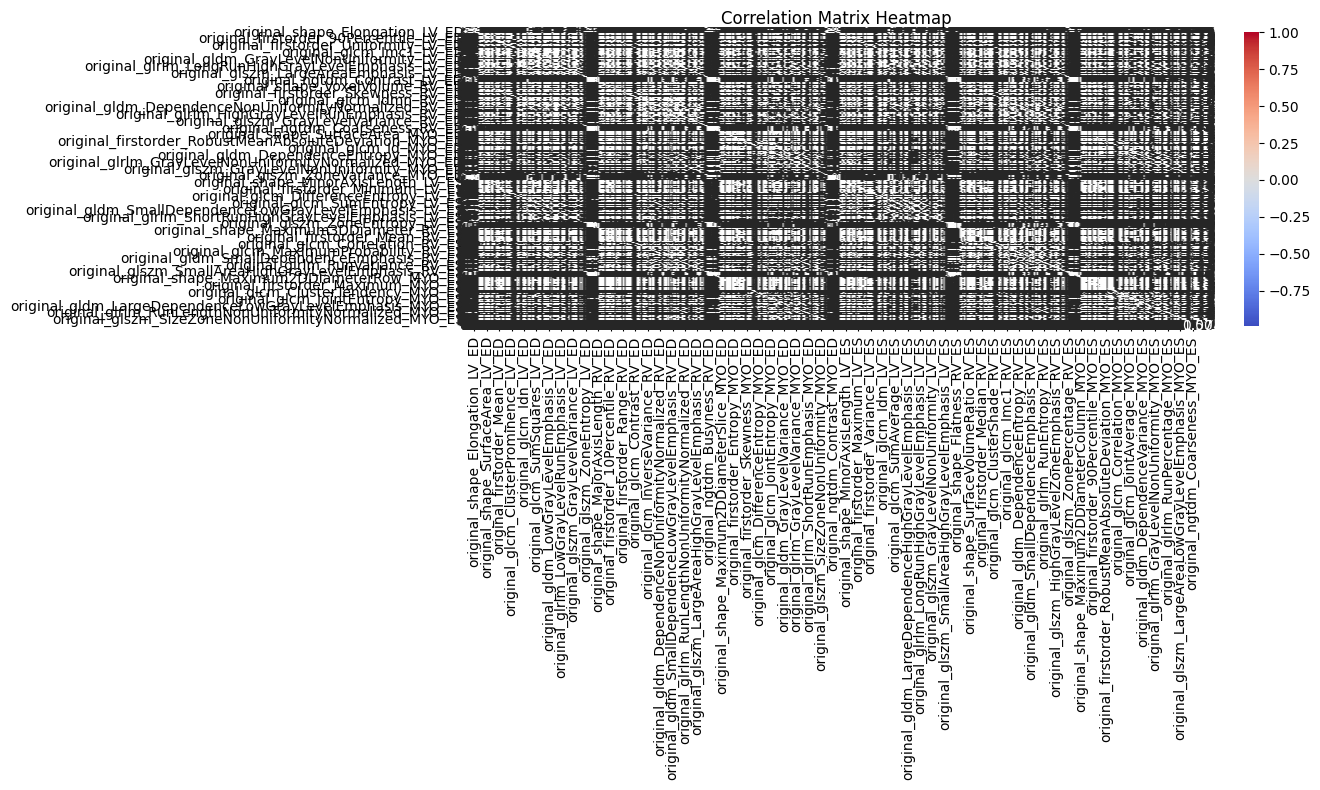

In [42]:

# Calculate the correlation matrix
correlation_matrix = X_standardized_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()


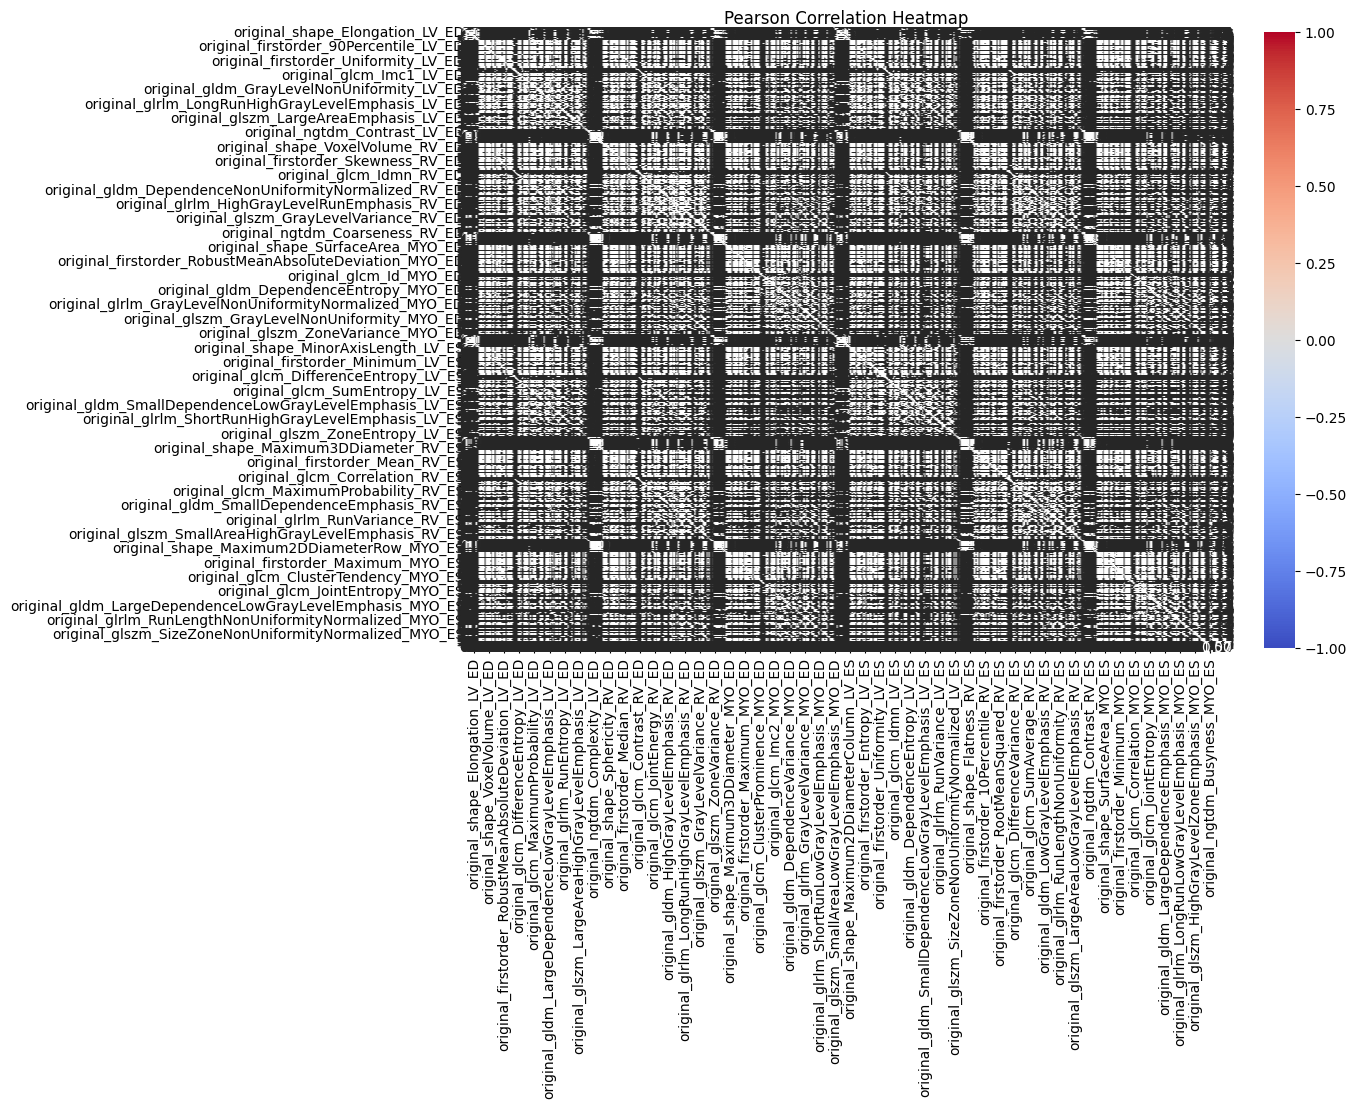

In [19]:
# Heatmap of Pearson Correlation
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Pearson Correlation Heatmap')
plt.show()

### 3. Spearman Rank Correlation. Spearman correlation as a non-parametric measure of rank-based method correlation.
This method is applied due to the data distribution which contain outliers and no-normal distribution \b
+1: Perfect increasing monotonic relationship.

-1: Perfect decreasing monotonic relationship.

0: No monotonic relationship.

In [18]:
# Spearman Correlation Matrix
spearman_corr_matrix = X_standardized_df.corr(method='spearman')

# Display Spearman correlation matrix
print("Spearman Correlation Matrix:\n", spearman_corr_matrix)

Spearman Correlation Matrix:
                                               original_shape_Elongation_LV_ED  \
original_shape_Elongation_LV_ED                                      1.000000   
original_shape_Flatness_LV_ED                                        0.295914   
original_shape_LeastAxisLength_LV_ED                                 0.049493   
original_shape_MajorAxisLength_LV_ED                                -0.433855   
original_shape_Maximum2DDiameterColumn_LV_ED                         0.191729   
...                                                                       ...   
original_ngtdm_Complexity_MYO_ES                                    -0.040696   
original_ngtdm_Contrast_MYO_ES                                       0.171341   
original_ngtdm_Strength_MYO_ES                                      -0.045785   
height                                                               0.051181   
weight                                                               0.178814  

In [19]:
## Identify strong correlation between features (|r| > 0.7) we redude the threa

strong_correlations = (spearman_corr_matrix.abs() > 0.4) & (spearman_corr_matrix != 1)  # Exclude diagonal

In [20]:
# Display Spearman Strong correlation matrix
print("Spearman Correlation Matrix:\n", strong_correlations)

Spearman Correlation Matrix:
                                               original_shape_Elongation_LV_ED  \
original_shape_Elongation_LV_ED                                         False   
original_shape_Flatness_LV_ED                                           False   
original_shape_LeastAxisLength_LV_ED                                    False   
original_shape_MajorAxisLength_LV_ED                                     True   
original_shape_Maximum2DDiameterColumn_LV_ED                            False   
...                                                                       ...   
original_ngtdm_Complexity_MYO_ES                                        False   
original_ngtdm_Contrast_MYO_ES                                          False   
original_ngtdm_Strength_MYO_ES                                          False   
height                                                                  False   
weight                                                                  False  

In [21]:
# Custom annotation: Show only strong correlations
annot = np.where(
    strong_correlations,
    spearman_corr_matrix.round(2).astype(str),
    ""
)

<Axes: >

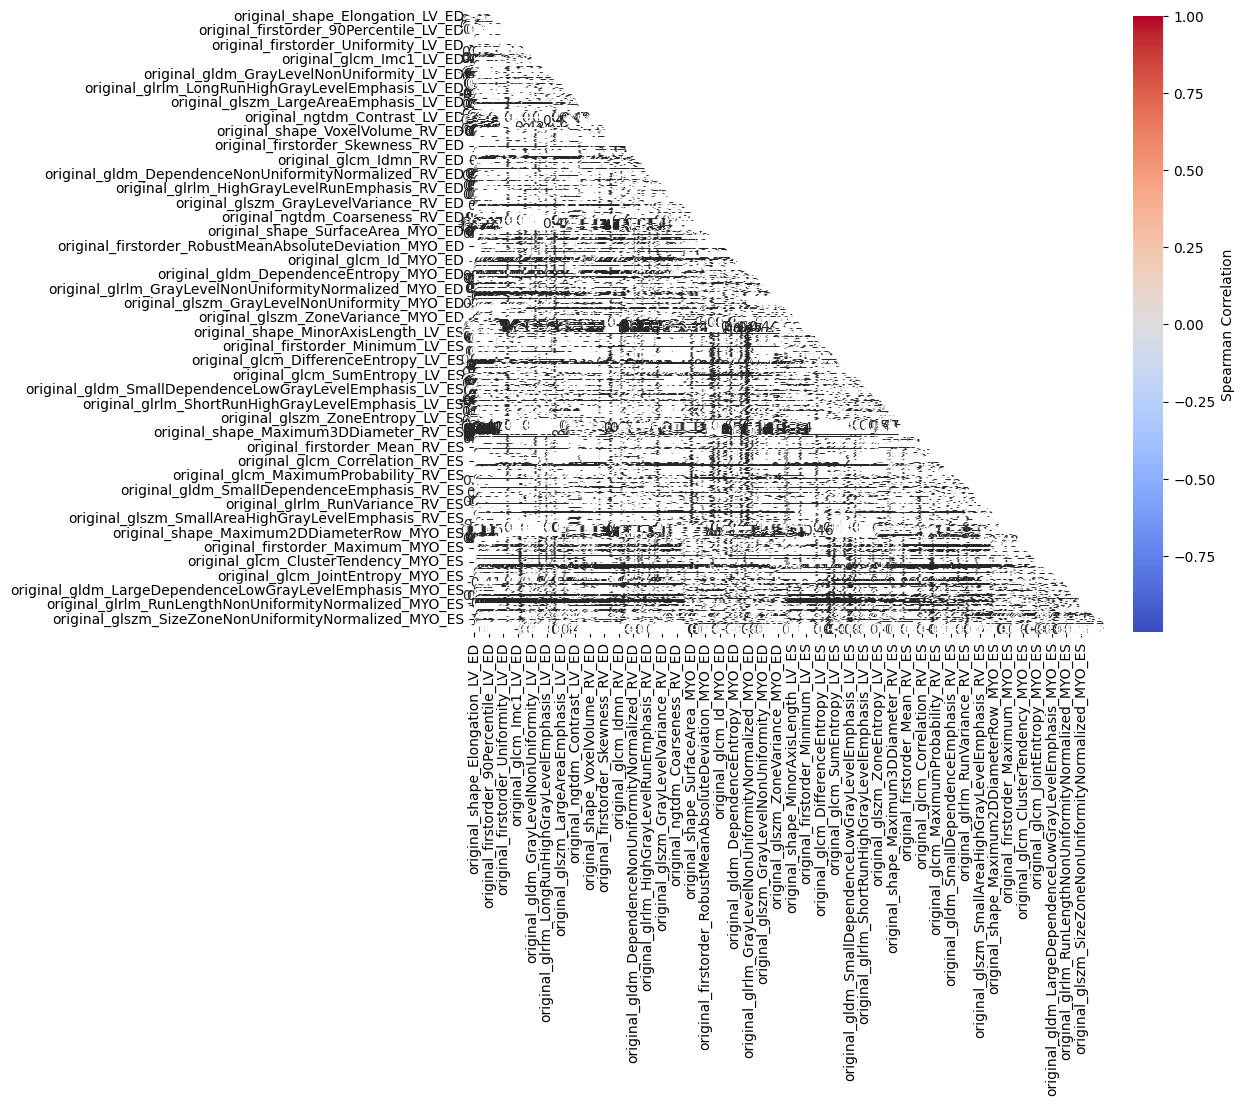

In [22]:
# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_corr_matrix,
    mask=np.triu(np.ones_like(spearman_corr_matrix, dtype=bool)),  # Show lower triangle only
    cmap='coolwarm',
    center=0,
    annot=annot,  # Only show strong correlations
    fmt='',       # Disable automatic formatting since we pre-formatted
    linewidths=0.5,
    cbar_kws={'label': 'Spearman Correlation'}
)

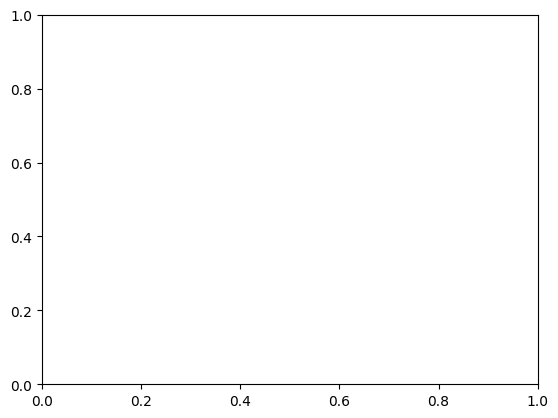

In [26]:
# Highlight strong correlations with a rectangle
for i in range(len(spearman_corr_matrix.columns)):
    for j in range(len(spearman_corr_matrix.columns)):
        if strong_correlations.iloc[i, j]:
            plt.gca().add_patch(plt.Rectangle(
                (j, i), 1, 1, fill=False, edgecolor='black', lw=2))

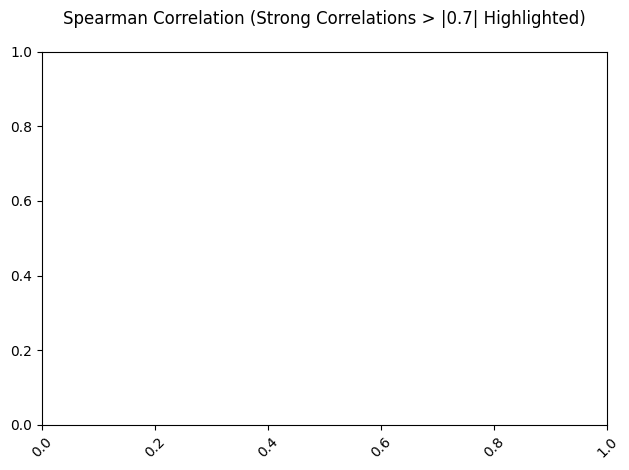

In [27]:
plt.title('Spearman Correlation (Strong Correlations > |0.7| Highlighted)', pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# Print strong correlation pairs
print("\nStrong Correlations (|r| > 0.7):")
for col in corr.columns:
    for idx in corr.index:
        if (abs(corr.loc[idx, col]) > 0.7) and (idx != col):
            print(f"{idx} & {col}: r = {corr.loc[idx, col]:.2f}")


Strong Correlations (|r| > 0.7):


NameError: name 'corr' is not defined

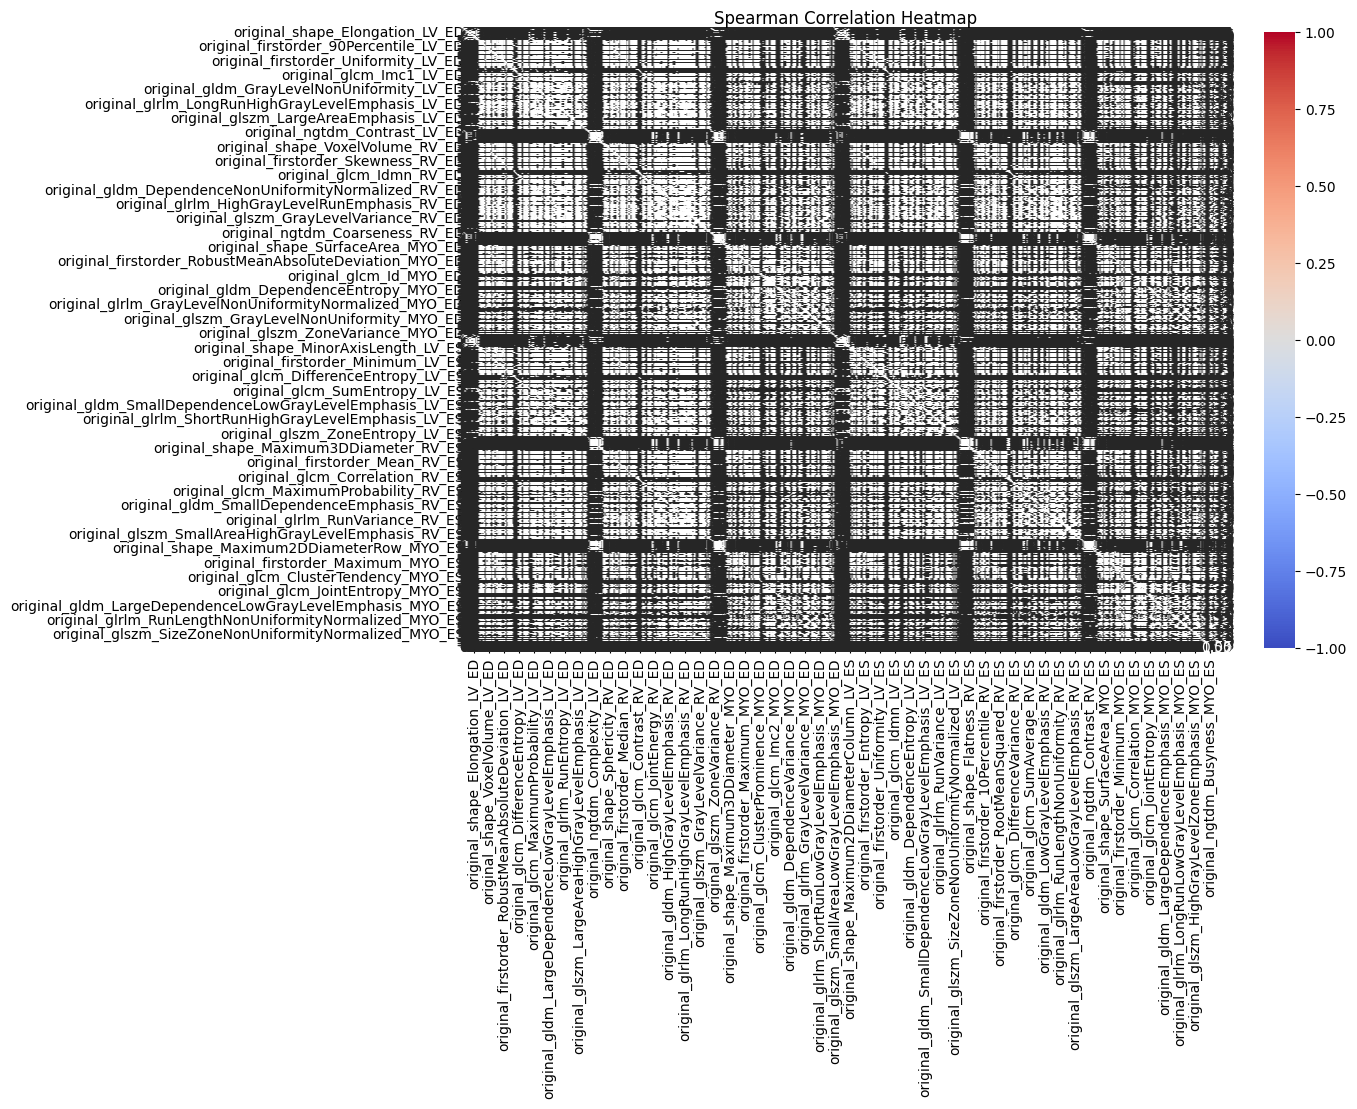

In [21]:
# Heatmap of Spearman Correlation
plt.figure(figsize=(12, 8))
sns.heatmap(spearman_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Spearman Correlation Heatmap')
plt.show()

Pairwise Correlation with Scatterplot Matrix. to visualize the pairwise correlation between specific features, and scatterplot matrix (pairplot) which shows scatter plots between each pair of features

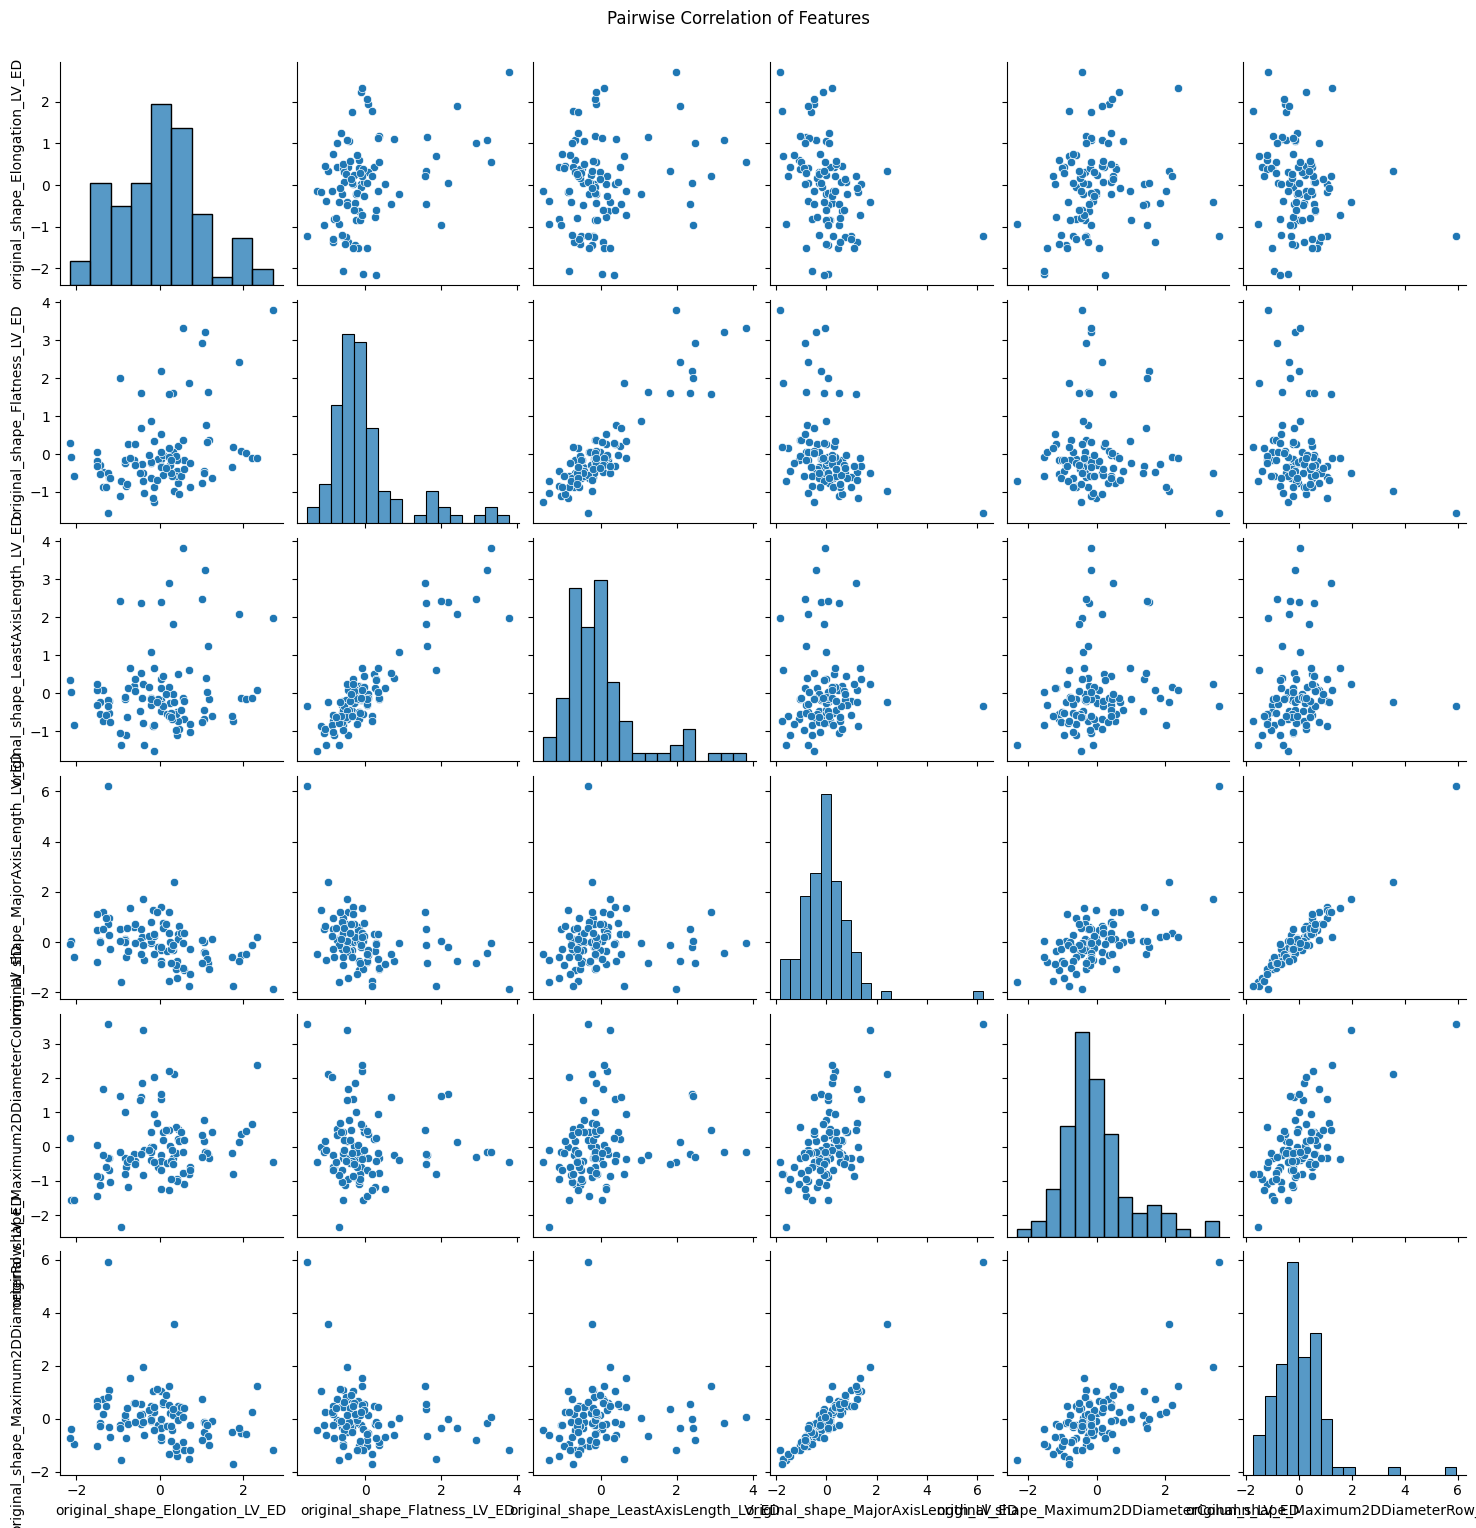

In [23]:
#Pairplot to visualize pairwise correlation
sns.pairplot(X_standardized_df[sample_features])
plt.suptitle('Pairwise Correlation of Features', y=1.02)
plt.show()

### Exploratory dimensionality reduction (PCA)

In [24]:
pca = PCA()
pca.fit(X_standardized_df)

# Varianza explicada acumulada
varianza_acumulada = pca.explained_variance_ratio_.cumsum()

# Por ejemplo, ver cuántos componentes necesitamos para alcanzar el 95%
import numpy as np
n_componentes_95 = np.argmax(varianza_acumulada >= 0.95) + 1

print(f"Components needed for 95% of varianze: {n_componentes_95}")

Components needed for 95% of varianze: 28


Gráfica de Codo (Scree Plot) Haces un gráfico de la varianza explicada por cada componente, y buscas el "codo" del gráfico, el punto donde agregar más componentes aporta muy poca varianza extra.

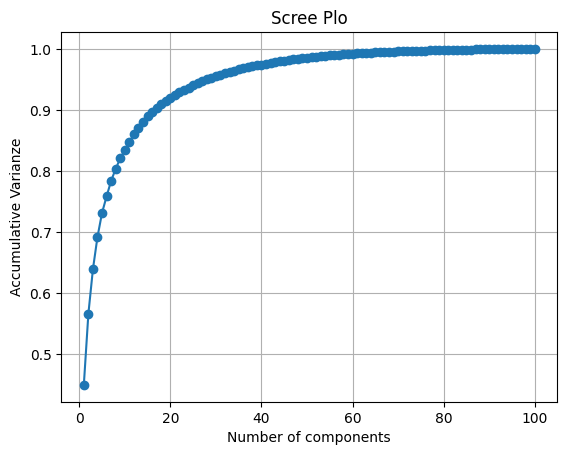

In [25]:

plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Accumulative Varianze')
plt.title('Scree Plo')
plt.grid()
plt.show()


In [26]:
# Create PCA instance and components
pca = PCA(n_components=28)
X_pca = pca.fit_transform(X_standardized_df)

# Display the explained variance ratio for each component
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

Explained Variance Ratio: [0.45013608 0.1164318  0.07303252 0.05279159 0.03934504 0.02700238
 0.02556019 0.01951001 0.01712036 0.01342008 0.01331723 0.01256352
 0.01086231 0.00983622 0.00871593 0.00723486 0.0065113  0.00597581
 0.00539902 0.00510339 0.00493851 0.00428703 0.00404544 0.00361663
 0.00351859 0.00344974 0.00333071 0.00302842]


3. Visualize the Explained Variance

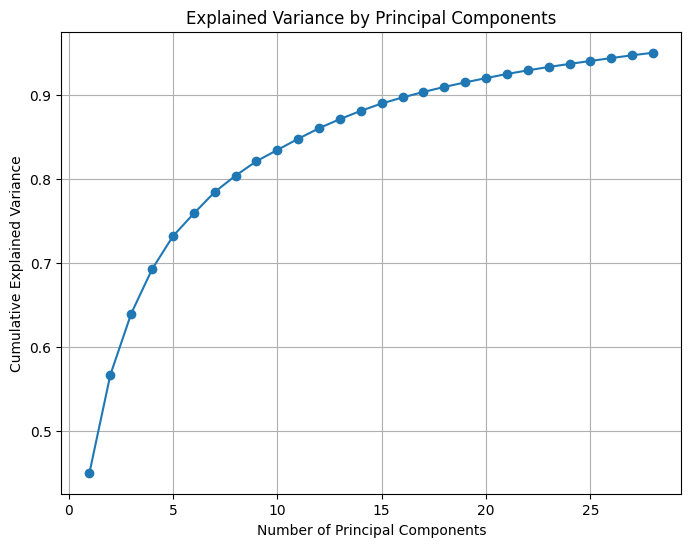

In [27]:
# Cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [28]:
# Convert class labels ('DCM', 'HCM', etc.) into numeric values
label_encoder = LabelEncoder()
y_numeric = label_encoder.fit_transform(y)  # Convert class labels to numeric

# Check the mapping from labels to numeric values
print("Label Encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Label Encoding: {'DCM': np.int64(0), 'HCM': np.int64(1), 'MINF': np.int64(2), 'NOR': np.int64(3), 'RV': np.int64(4)}


4. Visualize the Data After PCA (2D Projection)

In [29]:
X_pca

array([[ 14.13796155,   3.104926  ,  -7.82951554, ...,   0.78663919,
         -0.95043502,   0.19679363],
       [  6.47354849,   4.87909986,  -9.24347955, ...,  -0.7998559 ,
         -0.33432518,  -0.97029065],
       [  3.15573096,   4.69606885,  -7.69448579, ...,   0.13340379,
         -0.67430024,   0.1531767 ],
       ...,
       [-16.43108193,   3.07425617,  10.87456473, ...,  -1.04500971,
          0.56775805,   3.05475402],
       [ -9.4670587 ,  -1.32903018,   9.31033796, ...,   0.36971089,
         -0.62563857,  -0.38479279],
       [-10.09043201,  -5.17664696,   0.69274728, ...,   1.13861057,
          1.37578504,  -1.69344066]])

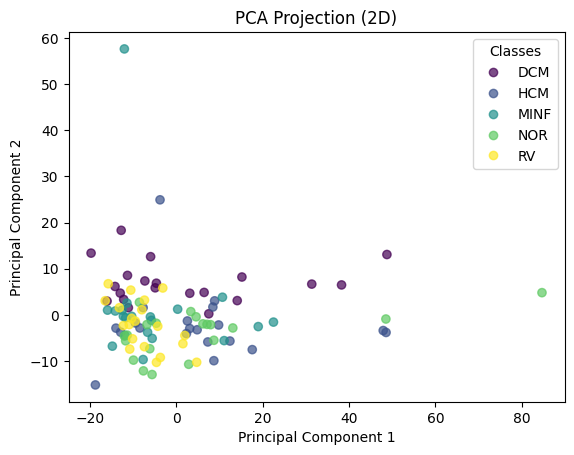

In [30]:
# Plot with a color map and add legend
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='viridis', alpha=0.7)
plt.title('PCA Projection (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Create a custom legend
handles, labels = scatter.legend_elements()
plt.legend(handles, label_encoder.classes_, title="Classes")
plt.show()

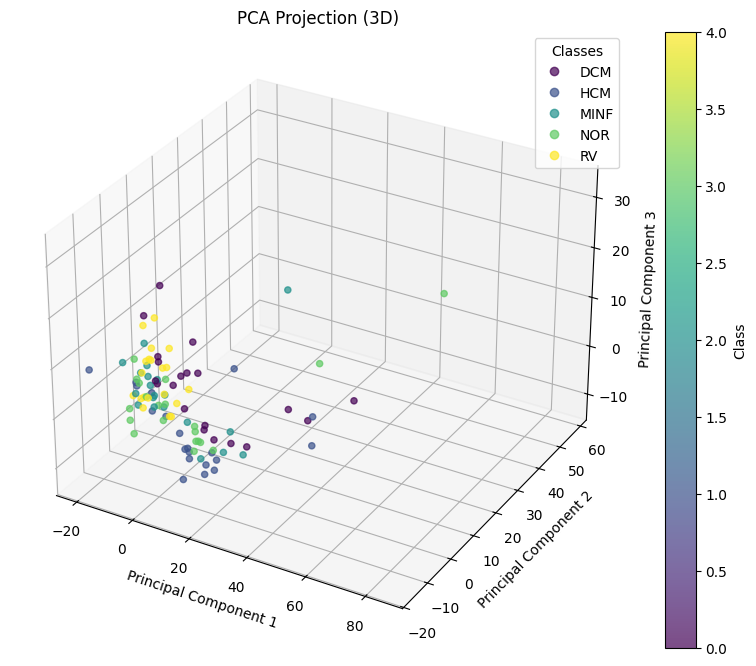

In [31]:


# 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y_numeric, cmap='viridis', alpha=0.7)

# Set labels and title
ax.set_title('PCA Projection (3D)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Add colorbar and legend
plt.colorbar(scatter, ax=ax, label='Class')

# Optionally, add a legend for the classes
handles, labels = scatter.legend_elements()
ax.legend(handles, label_encoder.classes_, title="Classes")

plt.show()

In [32]:
# Print the components (which features contribute the most to each principal component)
print("PCA Components (each row corresponds to a principal component):")
print(pca.components_)


PCA Components (each row corresponds to a principal component):
[[-0.00204585 -0.01291028 -0.01456009 ...  0.04977563 -0.0033003
  -0.00632036]
 [-0.0223419  -0.01563993  0.01665661 ...  0.00193425  0.01914115
  -0.00702291]
 [ 0.02389104  0.04513094  0.03884809 ...  0.02252131  0.020407
  -0.00239828]
 ...
 [ 0.0053009   0.00105985  0.01574533 ...  0.0213243  -0.07346652
  -0.03758443]
 [-0.13352359 -0.05811868 -0.01697129 ...  0.05481248 -0.01391725
  -0.11854138]
 [ 0.16628565  0.02328077 -0.04094395 ... -0.02681235 -0.03917744
  -0.17060263]]


In [33]:
#Visualizing component 1
pca.components_[0]

array([-0.00204585, -0.01291028, -0.01456009, -0.00398451, -0.00185726,
       -0.00554282, -0.00798232, -0.00557191, -0.01333108, -0.00464061,
       -0.00986168, -0.00982558,  0.01472445, -0.01332386,  0.0525113 ,
        0.05690109,  0.04973515,  0.05494154,  0.0540486 ,  0.01768216,
        0.05402977,  0.05598789,  0.05605666,  0.05503326, -0.00674497,
        0.05402948,  0.05453024,  0.05638643,  0.01430529,  0.04973515,
       -0.04935458,  0.05221947,  0.05356363,  0.03816126,  0.03132294,
        0.05112047,  0.04857114,  0.01195462,  0.05436231,  0.05363692,
        0.04552399, -0.05294074, -0.05296386,  0.00290724, -0.00824572,
        0.00703689,  0.02779874, -0.0191267 ,  0.05682639, -0.04525114,
        0.05473287,  0.01605662, -0.04624759,  0.05682639,  0.05432097,
        0.05120301,  0.0466391 ,  0.01234297,  0.05018783, -0.04347283,
       -0.03239488,  0.05221775,  0.05366702, -0.04419316,  0.03320055,
       -0.03965605, -0.04080672,  0.05475998,  0.04766309, -0.01

In [34]:


# loadings for PC1
loadings_pc1 = pca.components_[0]

abs_loadings_pc1 = [abs(val) for val in loadings_pc1]

sorted_indices = np.argsort(abs_loadings_pc1)[::-1]
sorted_loadings = [loadings_pc1[i] for i in sorted_indices]


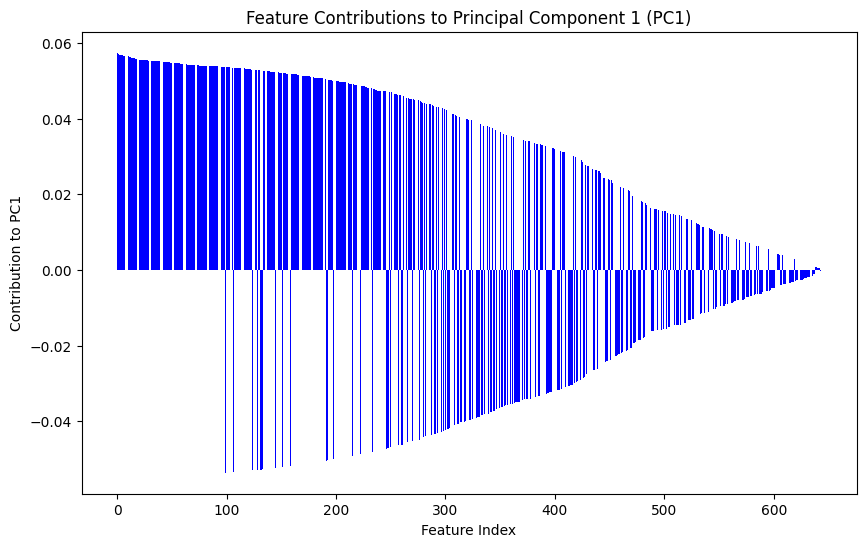

In [35]:


# Plot feature contributions to PC1
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_loadings)), sorted_loadings, color='blue')
plt.title("Feature Contributions to Principal Component 1 (PC1)")
plt.xlabel("Feature Index")
plt.ylabel("Contribution to PC1")
plt.show()


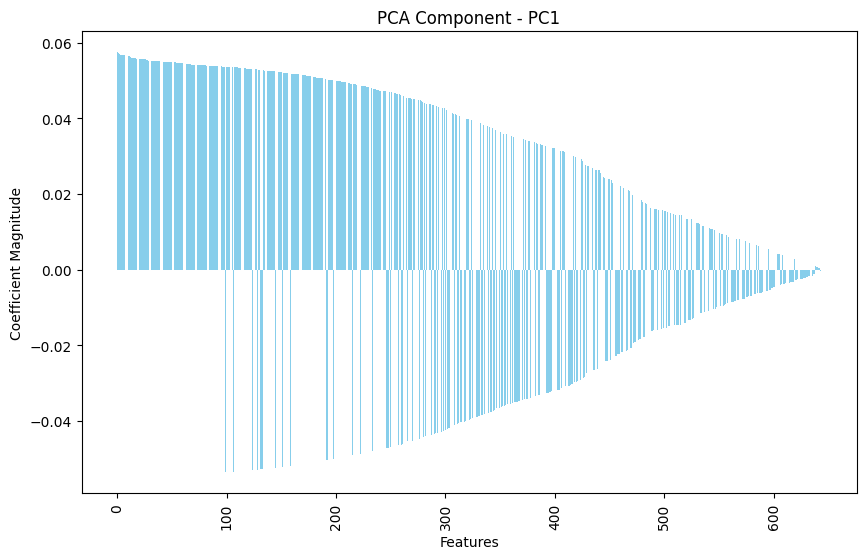

In [36]:


# Extract the PCA component for PC1 from the given data
pc1 = sorted_loadings

# Plotting the PCA Component (PC1)
plt.figure(figsize=(10, 6))
plt.bar(range(len(pc1)), pc1, color='skyblue')
plt.title("PCA Component - PC1")
plt.xlabel("Features")
plt.ylabel("Coefficient Magnitude")
plt.xticks(rotation=90)
plt.show()


In [37]:
#Visualizing component 2
pca.components_[1]

array([-2.23418976e-02, -1.56399335e-02,  1.66566102e-02,  9.49818655e-02,
        7.03268560e-02,  9.45860347e-02,  7.66234615e-02,  9.40111562e-02,
        6.64928416e-02,  6.94314018e-02, -4.93405655e-02,  9.33174872e-02,
       -6.51291902e-03,  6.66501651e-02,  4.98413359e-03,  5.52918139e-03,
        2.87896468e-02,  7.12412901e-03,  7.41592021e-03, -2.63132182e-04,
        8.55072818e-03,  6.11219629e-03,  4.39152708e-03,  3.34064445e-03,
       -6.65206679e-03,  8.91303506e-03,  7.11577130e-03,  4.48072632e-03,
        1.28311410e-02,  2.87896468e-02, -7.47980250e-03,  4.30218803e-03,
        5.82670450e-03,  1.57807771e-04,  2.50542109e-04,  5.03988454e-03,
        3.73321968e-04,  1.76879960e-02,  7.05999971e-04, -1.04417934e-03,
       -1.82387567e-04,  1.10316256e-03,  7.57442446e-04,  1.63675023e-02,
        1.77902003e-02, -3.23110613e-02,  1.63878419e-02, -1.35973778e-02,
        4.84406110e-03, -2.66367479e-03,  4.58247135e-03,  1.93995536e-02,
       -7.06409338e-03,  

In [38]:


loadings_pc2 = pca.components_[1]

abs_loadings_pc2 = [abs(val) for val in loadings_pc2]

sorted_indices2 = np.argsort(abs_loadings_pc2)[::-1]
sorted_loadings2 = [loadings_pc2[i] for i in sorted_indices2]

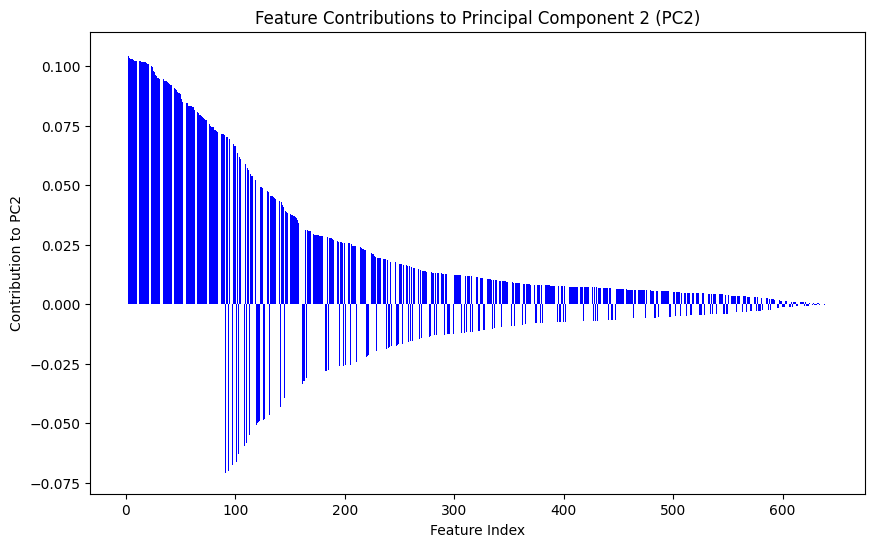

In [39]:




# Plot feature contributions to PC2
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_loadings2)), sorted_loadings2, color='blue')
plt.title("Feature Contributions to Principal Component 2 (PC2)")
plt.xlabel("Feature Index")
plt.ylabel("Contribution to PC2")
plt.show()

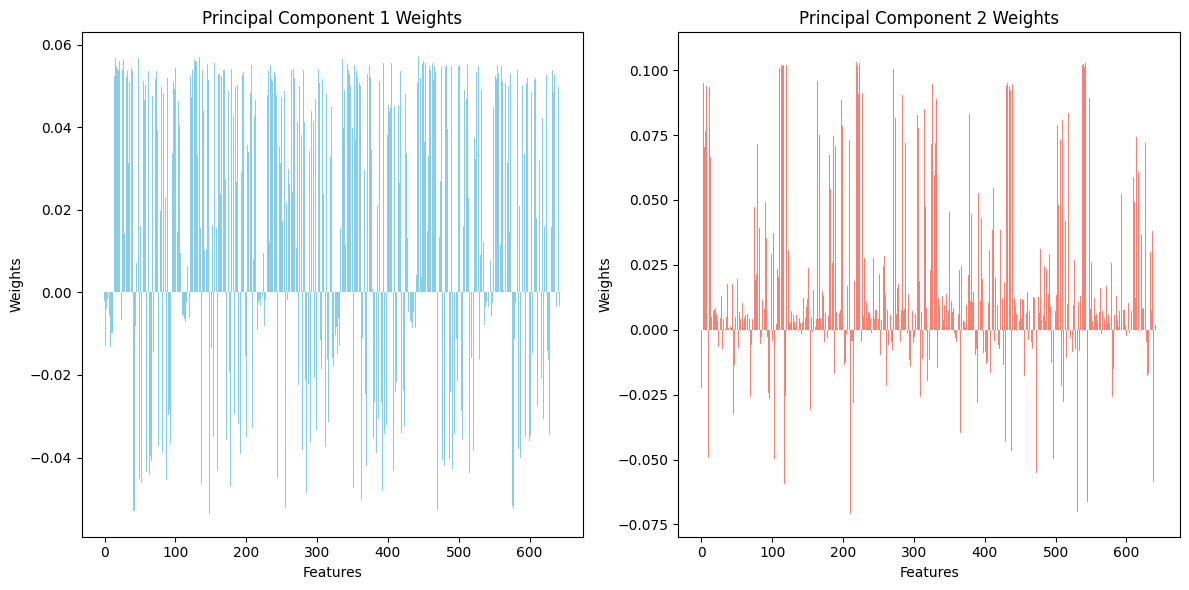

In [40]:


# Get the first few principal components (eigenvectors)
components = pca.components_  # Shape (n_components, n_features)

# Plot the first two components
plt.figure(figsize=(12, 6))

# Plot the first component
plt.subplot(1, 2, 1)
plt.bar(range(len(components[0])), components[0], color='skyblue')
plt.title("Principal Component 1 Weights")
plt.xlabel('Features')
plt.ylabel('Weights')

# Plot the second component
plt.subplot(1, 2, 2)
plt.bar(range(len(components[1])), components[1], color='salmon')
plt.title("Principal Component 2 Weights")
plt.xlabel('Features')
plt.ylabel('Weights')

plt.tight_layout()
plt.show()



In [41]:
components

array([[-0.00204585, -0.01291028, -0.01456009, ...,  0.04977563,
        -0.0033003 , -0.00632036],
       [-0.0223419 , -0.01563993,  0.01665661, ...,  0.00193425,
         0.01914115, -0.00702291],
       [ 0.02389104,  0.04513094,  0.03884809, ...,  0.02252131,
         0.020407  , -0.00239828],
       ...,
       [ 0.0053009 ,  0.00105985,  0.01574533, ...,  0.0213243 ,
        -0.07346652, -0.03758443],
       [-0.13352359, -0.05811868, -0.01697129, ...,  0.05481248,
        -0.01391725, -0.11854138],
       [ 0.16628565,  0.02328077, -0.04094395, ..., -0.02681235,
        -0.03917744, -0.17060263]])

### Exploratory dimensionality reduction t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE technique for dimensionality reduction, especially for high-dimensional data. It is well-suited for visualizing data in 2D or 3D and works by minimizing the divergence between probability distributions of pairwise similarities in higher and lower dimensions.

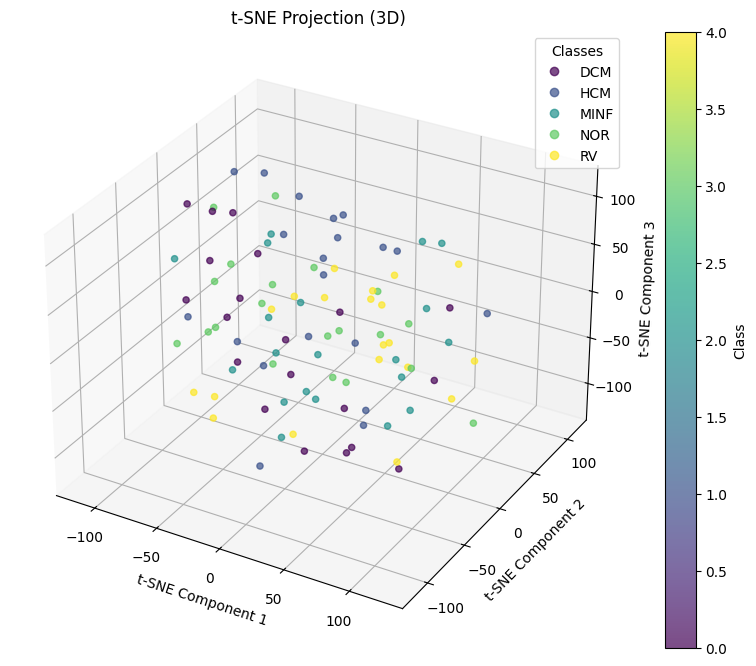

In [29]:
# Apply t-SNE for 2D or 3D visualization
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(X_normalized_df)

# 3D scatter plot of t-SNE projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=y_numeric, cmap='viridis', alpha=0.7)

# Set labels and title
ax.set_title('t-SNE Projection (3D)')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')

# Add colorbar and legend
plt.colorbar(scatter, ax=ax, label='Class')

# Optionally, add a legend for the classes
handles, labels = scatter.legend_elements()
ax.legend(handles, label_encoder.classes_, title="Classes")

plt.show()

Linear Discriminant Analysis (LDA) supervised dimensionality reduction technique that tries to find the directions (or components) that maximize the separation between multiple classes.

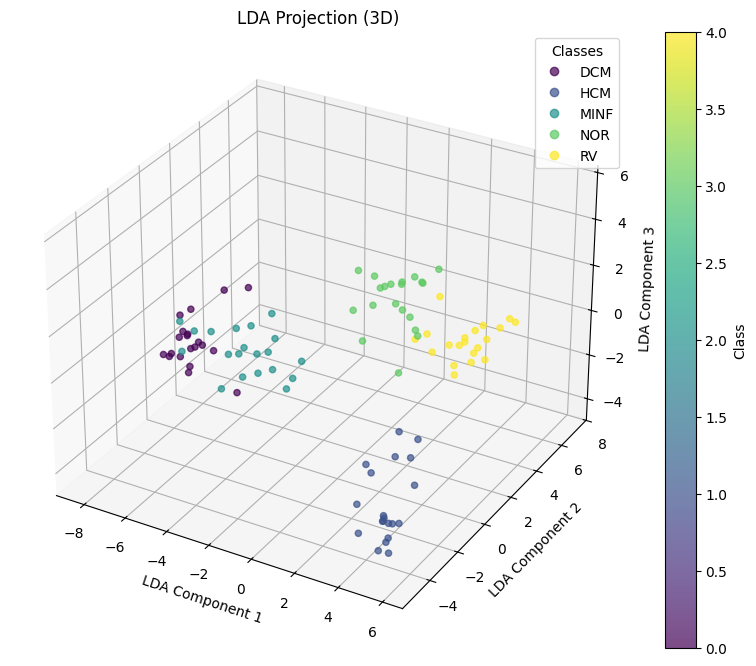

In [30]:
# Apply LDA for dimensionality reduction (usually for 2D, 3D)
lda = LinearDiscriminantAnalysis(n_components=3)
X_lda = lda.fit_transform(X_normalized_df, y)

# 3D scatter plot of LDA projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_lda[:, 0], X_lda[:, 1], X_lda[:, 2], c=y_numeric, cmap='viridis', alpha=0.7)

# Set labels and title
ax.set_title('LDA Projection (3D)')
ax.set_xlabel('LDA Component 1')
ax.set_ylabel('LDA Component 2')
ax.set_zlabel('LDA Component 3')

# Add colorbar and legend
plt.colorbar(scatter, ax=ax, label='Class')

# Optionally, add a legend for the classes
handles, labels = scatter.legend_elements()
ax.legend(handles, label_encoder.classes_, title="Classes")

plt.show()

UMAP (Uniform Manifold Approximation and Projection)  nonlinear dimensionality reduction technique that focuses on preserving both the local and global structure of data.

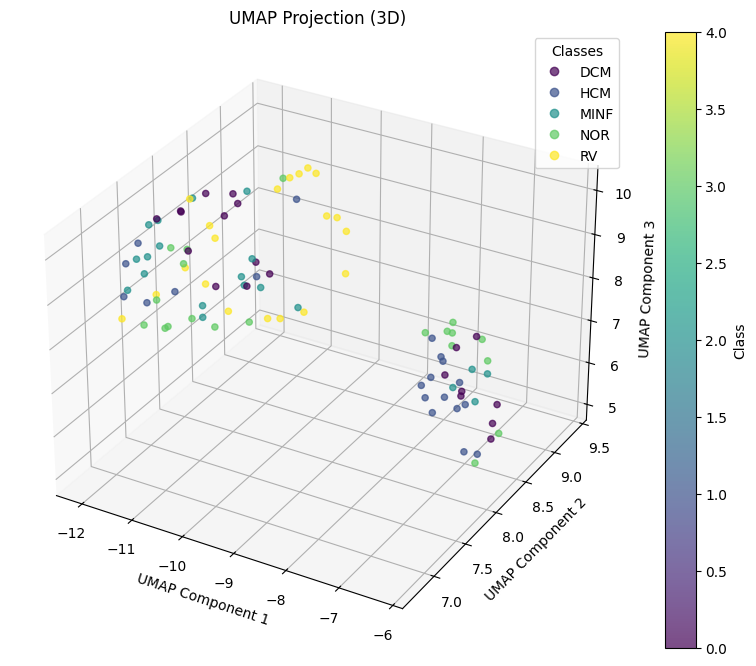

In [31]:
# Apply UMAP for 3D dimensionality reduction
umap_model = umap.UMAP(n_components=3)
X_umap = umap_model.fit_transform(X_normalized_df)

# 3D scatter plot of UMAP projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=y_numeric, cmap='viridis', alpha=0.7)

# Set labels and title
ax.set_title('UMAP Projection (3D)')
ax.set_xlabel('UMAP Component 1')
ax.set_ylabel('UMAP Component 2')
ax.set_zlabel('UMAP Component 3')

# Add colorbar and legend
plt.colorbar(scatter, ax=ax, label='Class')

# Optionally, add a legend for the classes
handles, labels = scatter.legend_elements()
ax.legend(handles, label_encoder.classes_, title="Classes")

plt.show()

# 3. Feature Selecction

### Low-variance feature removal
Low-variance feature removal is a technique used to remove features from the dataset that have little to no variation, as they generally do not contribute significantly to the model's performance. Features with low variance can make the model more complex without improving its predictive power.

Setting the Best Variance Threshold:

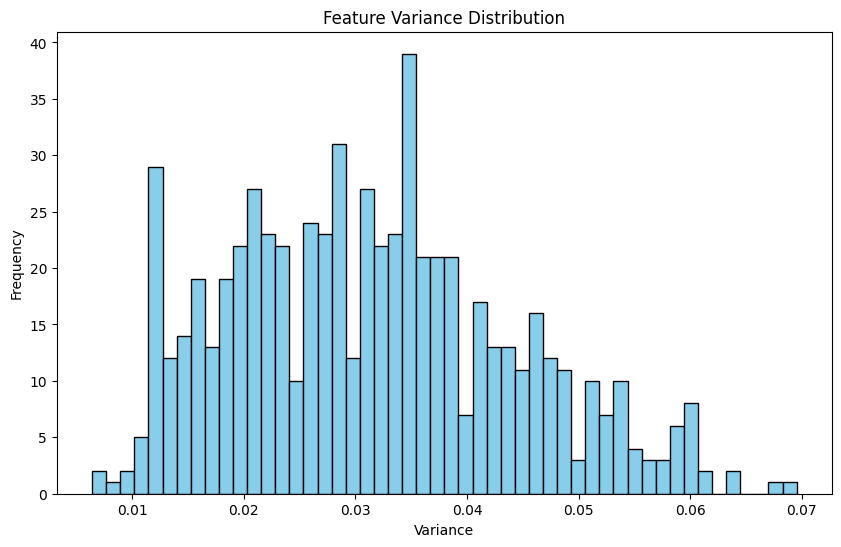

In [32]:
# Calculate the variance of each feature
feature_variances = np.var(X_normalized_df, axis=0)

# Plot the variance of each feature
plt.figure(figsize=(10, 6))
plt.hist(feature_variances, bins=50, color='skyblue', edgecolor='black')
plt.title('Feature Variance Distribution')
plt.xlabel('Variance')
plt.ylabel('Frequency')
plt.show()

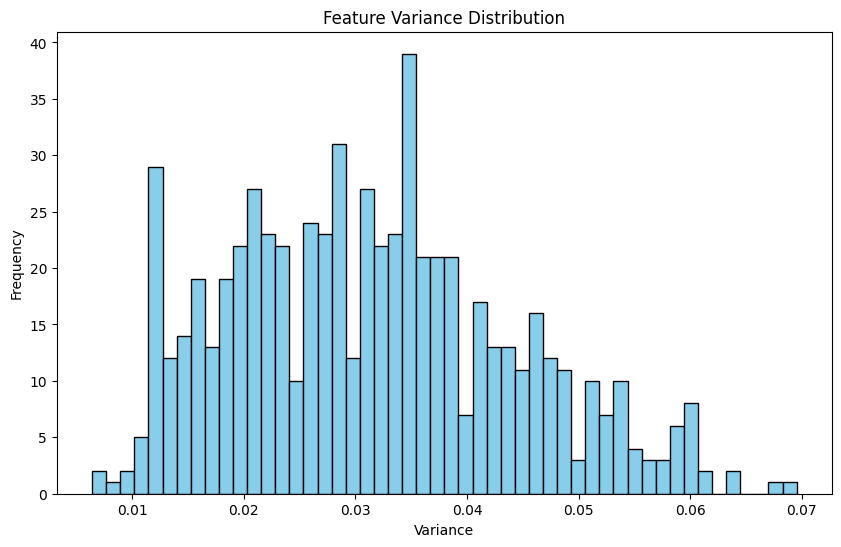

Min variance: 0.006414985571194004
Max variance: 0.06953127724580677
Mean variance: 0.03146212551399154


In [33]:
# Plot the variance of each feature to see the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(feature_variances, bins=50, color='skyblue', edgecolor='black')
plt.title('Feature Variance Distribution')
plt.xlabel('Variance')
plt.ylabel('Frequency')
plt.show()

# Display the minimum, maximum, and mean variance
print(f"Min variance: {np.min(feature_variances)}")
print(f"Max variance: {np.max(feature_variances)}")
print(f"Mean variance: {np.mean(feature_variances)}")

3. Removing Low-Variance Features Using a Different Strategy: due No feature in X meets the variance threshold 0.07000


In [34]:

# Use SelectKBest to select the top K features based on ANOVA F-test
selector = SelectKBest(f_classif, k=10)  # Select top 10 features
X_selected = selector.fit_transform(X_normalized_df, y)

# Get the selected feature indices
selected_features = X_normalized_df.columns[selector.get_support()]
print(f"Selected features: {selected_features}")

Selected features: Index(['original_shape_MajorAxisLength_RV_ES',
       'original_shape_Maximum2DDiameterRow_RV_ES',
       'original_shape_Maximum2DDiameterSlice_RV_ES',
       'original_shape_Maximum3DDiameter_RV_ES',
       'original_shape_MeshVolume_RV_ES',
       'original_shape_MinorAxisLength_RV_ES',
       'original_shape_SurfaceVolumeRatio_RV_ES',
       'original_shape_VoxelVolume_RV_ES',
       'original_glrlm_GrayLevelNonUniformity_RV_ES',
       'original_shape_Sphericity_MYO_ES'],
      dtype='object')


Use a Range of Thresholds for Feature Selection:



Lower the threshold to keep more features.

A typical starting point is threshold = 0.0 (remove only features with exactly zero variance — constant columns).

Then you can gradually increase the threshold to find a better value.

Since ACDC radiomic features are rich and complex, you should:


Step	What to do	Why
1	Start with a threshold = 0.0	Only remove features that are exactly constant.
2	Try small increases like 0.01, 0.02	To remove very low-variance features without losing important information.
3	Monitor how many features are left	If you lose too many features, your threshold is too high.
4	Use cross-validation to choose the best threshold	So you pick the threshold that optimizes model performance (not just feature count).

### Experimentation enviorament using the selected features and threashold

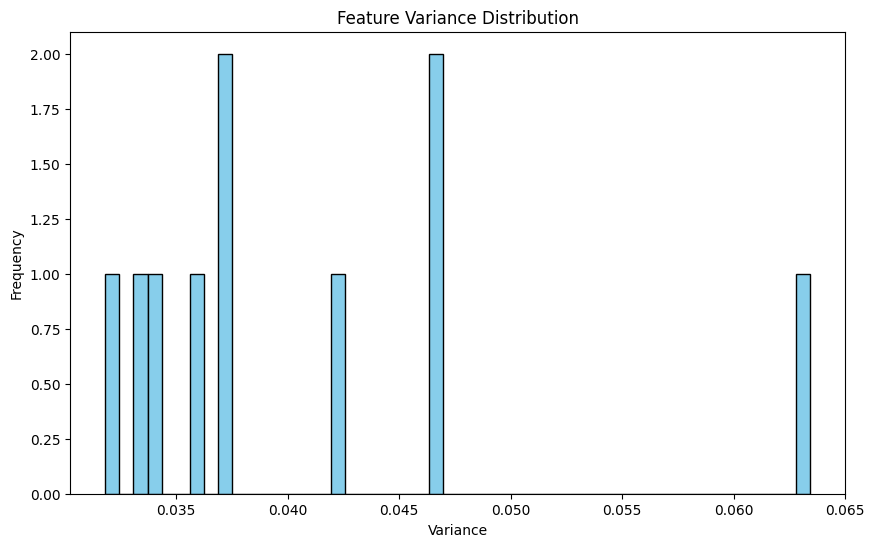

In [35]:
# Calculate the variance of each feature
feature_variances = np.var(X_selected, axis=0)

# Plot the variance of each feature
plt.figure(figsize=(10, 6))
plt.hist(feature_variances, bins=50, color='skyblue', edgecolor='black')
plt.title('Feature Variance Distribution')
plt.xlabel('Variance')
plt.ylabel('Frequency')
plt.show()

In [36]:
# data is X_normalized_df (features) and y (labels)

modelRandomForest = RandomForestClassifier(random_state=42)

# Create thresholds to test

thresholds = np.linspace(0.0, 0.05, 6)

results = []

# Loop over thresholds
for threshold in thresholds:
    selector = VarianceThreshold(threshold=threshold)
    X_selected = selector.fit_transform(X_normalized_df,y)
    print(f"Threshold {threshold:.2f} => {X_selected.shape[1]} features")

    if X_selected.shape[1] > 0:  # Make sure there are still features left
        score = cross_val_score(modelRandomForest, X_selected, y, cv=5).mean()
        results.append((threshold, score))
    else:
        results.append((threshold, 0))  # if no features left, assign score 0

# Store in a DataFrame
results_df = pd.DataFrame(results, columns=['Threshold', 'CV Score'])

Threshold 0.00 => 644 features
Threshold 0.01 => 640 features
Threshold 0.02 => 513 features
Threshold 0.03 => 336 features
Threshold 0.04 => 155 features
Threshold 0.05 => 60 features


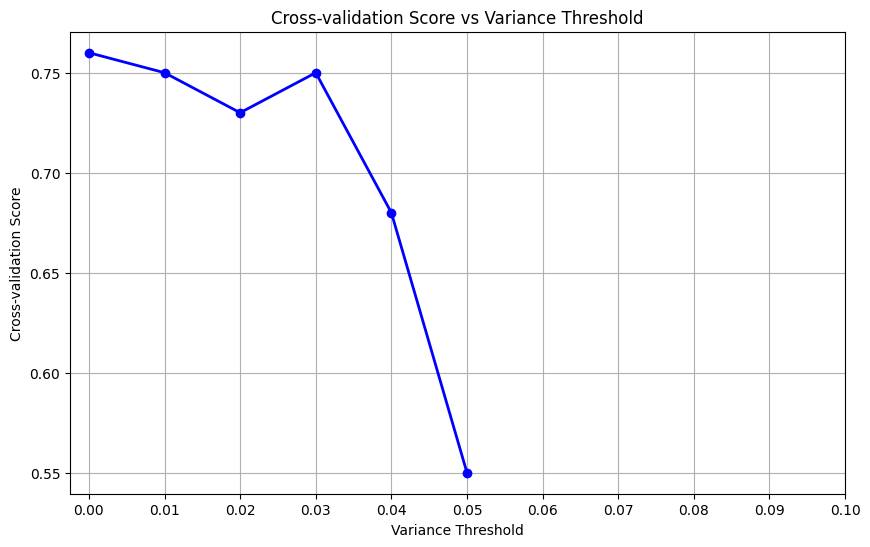

Best threshold: 0.0 with CV score: 0.76


In [37]:
# Plot the results: Cross-validation score vs Variance threshold
plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['CV Score'], marker='o', color='blue', linestyle='-', linewidth=2)
plt.title('Cross-validation Score vs Variance Threshold')
plt.xlabel('Variance Threshold')
plt.ylabel('Cross-validation Score')
plt.grid(True)
plt.xticks(np.arange(0.0, 0.11, step=0.01))
plt.show()

# Display the best threshold based on cross-validation score
best_threshold = results_df.loc[results_df['CV Score'].idxmax()]
print(f'Best threshold: {best_threshold["Threshold"]} with CV score: {best_threshold["CV Score"]}')

### Test using SVM

Threshold 0.00 => 644 features
Threshold 0.00 => 644 features
Threshold 0.01 => 644 features
Threshold 0.01 => 642 features
Threshold 0.01 => 638 features
Threshold 0.01 => 602 features
Threshold 0.02 => 572 features
Threshold 0.02 => 537 features
Threshold 0.02 => 489 features
Threshold 0.02 => 439 features
Threshold 0.03 => 406 features
Threshold 0.03 => 350 features
Threshold 0.03 => 309 features
Threshold 0.03 => 260 features
Threshold 0.04 => 199 features
Threshold 0.04 => 158 features
Threshold 0.04 => 132 features
Threshold 0.04 => 105 features
Threshold 0.05 => 79 features
Threshold 0.05 => 60 features


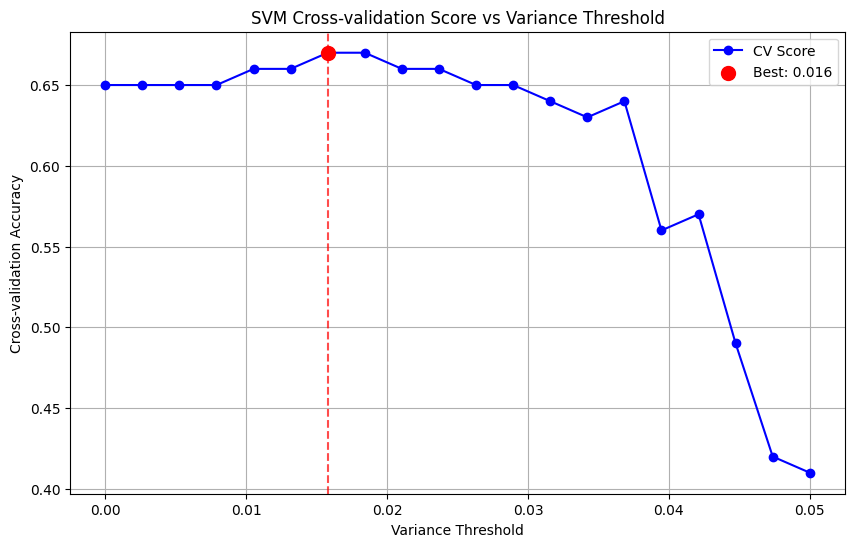


🏆 Best threshold: 0.016 with CV Accuracy: 0.6700


In [38]:




# Define range of thresholds to try
thresholds = np.linspace(0, 0.05, 20)  # from 0 to 0.05 in 20 steps
cv_scores = []
resultsSVM = []

for threshold in thresholds:
    # Feature Selection
    selector = VarianceThreshold(threshold=threshold)
    try:
        X_selected = selector.fit_transform(X_normalized_df)

        if X_selected.shape[1] == 0:
            # No features left, skip
            cv_scores.append(0)
            continue
        print(f"Threshold {threshold:.2f} => {X_selected.shape[1]} features")
        # Model: SVM
        svm = SVC(kernel='rbf', random_state=42)

        # Cross-validation
        if X_selected.shape[1] > 0:  # Make sure there are still features left
          scores = cross_val_score(svm, X_selected, y, cv=5, scoring='accuracy')
          cv_scores.append(scores.mean())
          resultsSVM.append((threshold, score))
        else:
          resultsSVM.append((threshold, 0))  # if no features left, assign score 0



    except Exception as e:
        print(f"Error at threshold {threshold}: {e}")
        cv_scores.append(0)

# Convert to arrays
thresholds = np.array(thresholds)
cv_scores = np.array(cv_scores)

# Find best threshold
best_idx = np.argmax(cv_scores)
best_threshold = thresholds[best_idx]
best_score = cv_scores[best_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, cv_scores, marker='o', linestyle='-', color='blue', label='CV Score')
plt.scatter(best_threshold, best_score, color='red', s=100, label=f'Best: {best_threshold:.3f}', zorder=5)
plt.axvline(x=best_threshold, color='red', linestyle='--', alpha=0.7)
plt.title('SVM Cross-validation Score vs Variance Threshold')
plt.xlabel('Variance Threshold')
plt.ylabel('Cross-validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f"\n🏆 Best threshold: {best_threshold:.3f} with CV Accuracy: {best_score:.4f}")


After a consideration for experiments using PCA, Absolute Loading Weights and
Approach: PCA-Weighted Features for Model-Based Selection

# Experimentation

### Model-based selection - Test Using multiple models
automatically pick the final model after evaluating all folds by selecting the one with the best average test performance.
Workflow:
Start with variance-ratio thresholding (Method B) for balanced feature reduction.

Use GridSearchCV to fine-tune the percentile threshold for your best-performing model.

Comparation results against baseline (original features) and other methods (PCA weighting).





In [42]:
def plot_conf_matrix(cm, model_name, class_names):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                square=True, cbar=False, linewidths=0.5, linecolor='gray')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


In [43]:
# Automatically get sorted unique class labels from your data
class_names = [str(label) for label in np.unique(y)]

### Experiment 1
Combination thresholding with PCA-weighted features to avoid losing weak but cumulative signals.

Step 1: Statistical Threshold Selection. Method B: Variance-Ratio Threshold

In [44]:
# Compute absolute combined loadings (PC1 + PC2)
feature_weights = np.abs(loadings_pc1) + np.abs(loadings_pc2)

# Normalize weights to sum to 1
feature_weights /= np.sum(feature_weights)

# Apply weights to the original data
X_weighted = X_standardized_df * feature_weights

Step 2: Evaluate Models on Weighted Features

In [45]:
# Define models
models = {
    "SVM": SVC(random_state=42, kernel='rbf', C=1.0, gamma='scale'),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', solver='lbfgs'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=3),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

#Ejecutamos para modelo reducido con PCA


Evaluating SVM...
  Fold 1: Acc=0.7000, Prec=0.7667, Rec=0.7000, F1=0.7133
  Fold 2: Acc=0.8000, Prec=0.6667, Rec=0.8000, F1=0.7200
  Fold 3: Acc=0.8000, Prec=0.8000, Rec=0.8000, F1=0.8000
  Fold 4: Acc=0.5000, Prec=0.6500, Rec=0.5000, F1=0.5333
  Fold 5: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 6: Acc=0.7000, Prec=0.8000, Rec=0.7000, F1=0.7000
  Fold 7: Acc=0.9000, Prec=0.9333, Rec=0.9000, F1=0.8933
  Fold 8: Acc=0.8000, Prec=0.8667, Rec=0.8000, F1=0.7867
  Fold 9: Acc=0.9000, Prec=0.9333, Rec=0.9000, F1=0.8933
  Fold 10: Acc=0.8000, Prec=0.8667, Rec=0.8000, F1=0.7867
\Confusion Matrix Results SVM:
[[17  0  2  1  0]
 [ 1 14  0  5  0]
 [ 4  0 12  4  0]
 [ 0  2  1 16  1]
 [ 1  0  0  2 17]]


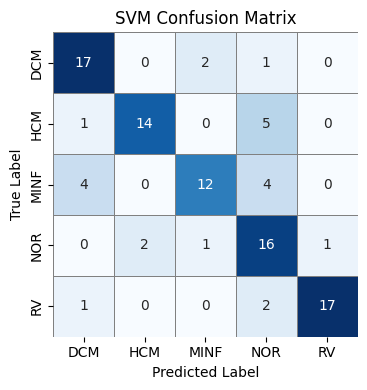


Average for SVM:
  Accuracy:  0.7600
  Precision: 0.8117
  Recall:    0.7600
  F1-Score:  0.7520
------------------------------------------------------------

Evaluating Random Forest...
  Fold 1: Acc=0.6000, Prec=0.5000, Rec=0.6000, F1=0.5333
  Fold 2: Acc=0.8000, Prec=0.6667, Rec=0.8000, F1=0.7200
  Fold 3: Acc=0.8000, Prec=0.9000, Rec=0.8000, F1=0.8000
  Fold 4: Acc=0.6000, Prec=0.6667, Rec=0.6000, F1=0.6133
  Fold 5: Acc=0.9000, Prec=0.9333, Rec=0.9000, F1=0.8933
  Fold 6: Acc=0.7000, Prec=0.7333, Rec=0.7000, F1=0.6933
  Fold 7: Acc=0.9000, Prec=0.9333, Rec=0.9000, F1=0.8933
  Fold 8: Acc=0.9000, Prec=0.9333, Rec=0.9000, F1=0.8933
  Fold 9: Acc=0.8000, Prec=0.6667, Rec=0.8000, F1=0.7200
  Fold 10: Acc=0.9000, Prec=0.9333, Rec=0.9000, F1=0.8933
\Confusion Matrix Results Random Forest:
[[18  0  2  0  0]
 [ 1 11  2  6  0]
 [ 2  0 14  3  1]
 [ 0  1  0 17  2]
 [ 0  0  0  1 19]]


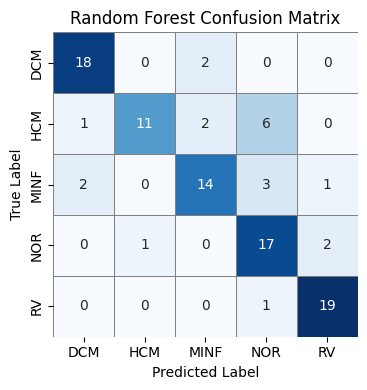


Average for Random Forest:
  Accuracy:  0.7900
  Precision: 0.7867
  Recall:    0.7900
  F1-Score:  0.7653
------------------------------------------------------------

Evaluating Logistic Regression...
  Fold 1: Acc=0.5000, Prec=0.5800, Rec=0.5000, F1=0.4810
  Fold 2: Acc=0.6000, Prec=0.4333, Rec=0.6000, F1=0.4933
  Fold 3: Acc=0.5000, Prec=0.5800, Rec=0.5000, F1=0.4810
  Fold 4: Acc=0.4000, Prec=0.3000, Rec=0.4000, F1=0.3400
  Fold 5: Acc=0.5000, Prec=0.4000, Rec=0.5000, F1=0.4400
  Fold 6: Acc=0.4000, Prec=0.2133, Rec=0.4000, F1=0.2743
  Fold 7: Acc=0.8000, Prec=0.7000, Rec=0.8000, F1=0.7333
  Fold 8: Acc=0.8000, Prec=0.8667, Rec=0.8000, F1=0.7867
  Fold 9: Acc=0.7000, Prec=0.6000, Rec=0.7000, F1=0.6333
  Fold 10: Acc=0.7000, Prec=0.8000, Rec=0.7000, F1=0.7000
\Confusion Matrix Results Logistic Regression:
[[16  1  3  0  0]
 [ 1 10  3  3  3]
 [ 3  0  9  3  5]
 [ 0  4  0  6 10]
 [ 1  0  0  1 18]]


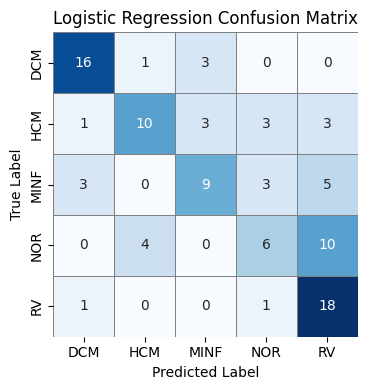


Average for Logistic Regression:
  Accuracy:  0.5900
  Precision: 0.5473
  Recall:    0.5900
  F1-Score:  0.5363
------------------------------------------------------------

Evaluating Decision Tree...
  Fold 1: Acc=0.6000, Prec=0.5500, Rec=0.6000, F1=0.5667
  Fold 2: Acc=0.6000, Prec=0.4800, Rec=0.6000, F1=0.5143
  Fold 3: Acc=0.6000, Prec=0.6133, Rec=0.6000, F1=0.5410
  Fold 4: Acc=0.6000, Prec=0.5800, Rec=0.6000, F1=0.5476
  Fold 5: Acc=0.7000, Prec=0.7333, Rec=0.7000, F1=0.6933
  Fold 6: Acc=0.6000, Prec=0.5500, Rec=0.6000, F1=0.5667
  Fold 7: Acc=0.7000, Prec=0.6000, Rec=0.7000, F1=0.6333
  Fold 8: Acc=0.7000, Prec=0.6333, Rec=0.7000, F1=0.6267
  Fold 9: Acc=0.7000, Prec=0.6800, Rec=0.7000, F1=0.6476
  Fold 10: Acc=0.7000, Prec=0.6333, Rec=0.7000, F1=0.6267
\Confusion Matrix Results Decision Tree:
[[18  0  1  0  1]
 [ 0  4  2 14  0]
 [ 1  2 15  1  1]
 [ 0  5  1 13  1]
 [ 1  0  0  4 15]]


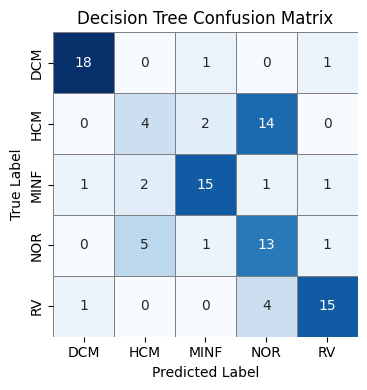


Average for Decision Tree:
  Accuracy:  0.6500
  Precision: 0.6053
  Recall:    0.6500
  F1-Score:  0.5964
------------------------------------------------------------

Evaluating KNN...
  Fold 1: Acc=0.6000, Prec=0.6667, Rec=0.6000, F1=0.5667
  Fold 2: Acc=0.5000, Prec=0.5000, Rec=0.5000, F1=0.5000
  Fold 3: Acc=0.8000, Prec=0.8000, Rec=0.8000, F1=0.8000
  Fold 4: Acc=0.5000, Prec=0.6500, Rec=0.5000, F1=0.5333
  Fold 5: Acc=0.7000, Prec=0.7667, Rec=0.7000, F1=0.6867
  Fold 6: Acc=0.7000, Prec=0.8000, Rec=0.7000, F1=0.7000
  Fold 7: Acc=0.9000, Prec=0.9333, Rec=0.9000, F1=0.8933
  Fold 8: Acc=0.5000, Prec=0.3667, Rec=0.5000, F1=0.4133
  Fold 9: Acc=0.8000, Prec=0.9000, Rec=0.8000, F1=0.8000
  Fold 10: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
\Confusion Matrix Results KNN:
[[16  0  3  1  0]
 [ 1 13  1  5  0]
 [ 4  0 10  6  0]
 [ 2  0  3 15  0]
 [ 1  0  1  5 13]]


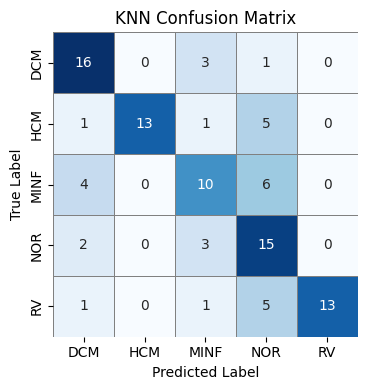


Average for KNN:
  Accuracy:  0.6700
  Precision: 0.7217
  Recall:    0.6700
  F1-Score:  0.6587
------------------------------------------------------------


In [55]:
#Use Stratified KFold to evaluate each model

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)



weighted_scores = {}
# Store detailed metrics
weighted_scores = {model_name: {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': []
} for model_name in models.keys()}

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    fold = 1

    all_preds = []
    all_trues = []

    for train_idx, val_idx in kfold.split(X_weighted, y):
        X_train, X_val = X_weighted.iloc[train_idx], X_weighted.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        all_preds.extend(y_pred)
        all_trues.extend(y[val_idx])

        # Collect metrics
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_val, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

        weighted_scores[model_name]['accuracy'].append(acc)
        weighted_scores[model_name]['precision'].append(prec)
        weighted_scores[model_name]['recall'].append(rec)
        weighted_scores[model_name]['f1_score'].append(f1)

        print(f"  Fold {fold}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")
        fold += 1
        # Print averages

    cm = confusion_matrix(all_trues, all_preds)
    print(f"\Confusion Matrix Results {model_name}:")
    print(cm)
    plot_conf_matrix(cm, model_name, class_names)
    print(f"\nAverage for {model_name}:")
    print(f"  Accuracy:  {np.mean(weighted_scores[model_name]['accuracy']):.4f}")
    print(f"  Precision: {np.mean(weighted_scores[model_name]['precision']):.4f}")
    print(f"  Recall:    {np.mean(weighted_scores[model_name]['recall']):.4f}")
    print(f"  F1-Score:  {np.mean(weighted_scores[model_name]['f1_score']):.4f}")
    print("-" * 60)



#Ejecutamos contra los datos originales para comparar


Evaluating SVM...
  Fold 1: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 2: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 3: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 4: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 5: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 6: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 7: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 8: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 9: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 10: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933


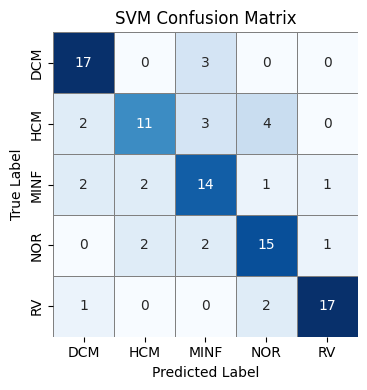


Average for SVM:
  Accuracy:  0.7000
  Precision: 0.8333
  Recall:    0.7000
  F1-Score:  0.6933
------------------------------------------------------------

Evaluating Random Forest...
  Fold 1: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 2: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 3: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 4: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 5: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 6: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 7: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 8: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 9: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 10: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933


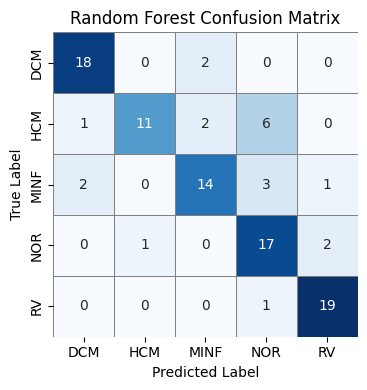


Average for Random Forest:
  Accuracy:  0.7000
  Precision: 0.8333
  Recall:    0.7000
  F1-Score:  0.6933
------------------------------------------------------------

Evaluating Logistic Regression...
  Fold 1: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 2: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 3: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 4: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 5: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 6: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 7: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 8: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 9: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 10: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933


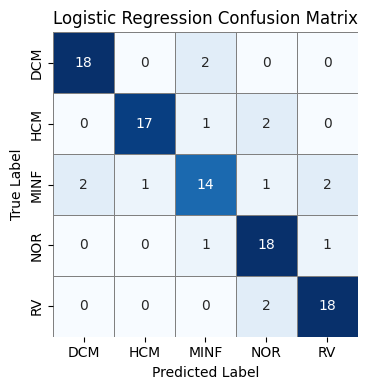


Average for Logistic Regression:
  Accuracy:  0.7000
  Precision: 0.8333
  Recall:    0.7000
  F1-Score:  0.6933
------------------------------------------------------------

Evaluating Decision Tree...
  Fold 1: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 2: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 3: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 4: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 5: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 6: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 7: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 8: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 9: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 10: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933


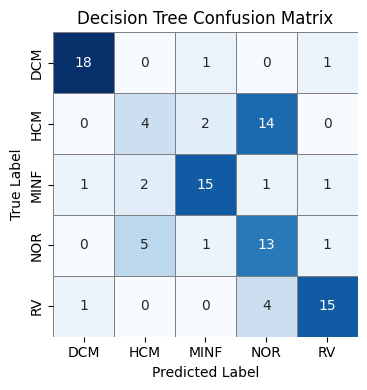


Average for Decision Tree:
  Accuracy:  0.7000
  Precision: 0.8333
  Recall:    0.7000
  F1-Score:  0.6933
------------------------------------------------------------

Evaluating KNN...
  Fold 1: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 2: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 3: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 4: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 5: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 6: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 7: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 8: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 9: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933
  Fold 10: Acc=0.7000, Prec=0.8333, Rec=0.7000, F1=0.6933


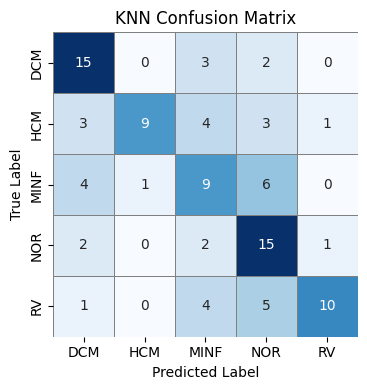


Average for KNN:
  Accuracy:  0.7000
  Precision: 0.8333
  Recall:    0.7000
  F1-Score:  0.6933
------------------------------------------------------------


In [50]:
#Use Stratified KFold to evaluate each model

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)



original_scores = {}
# Store detailed metrics
original_scores = {model_name: {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': []
} for model_name in models.keys()}

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    fold = 1

    all_preds = []
    all_trues = []

    for train_idx, val_idx in kfold.split(X_standardized_df, y):
        X_train, X_val = X_standardized_df.iloc[train_idx], X_standardized_df.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_predO = model.predict(X_val)

        all_preds.extend(y_predO)
        all_trues.extend(y[val_idx])

        # Collect metrics
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_val, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

        original_scores[model_name]['accuracy'].append(acc)
        original_scores[model_name]['precision'].append(prec)
        original_scores[model_name]['recall'].append(rec)
        original_scores[model_name]['f1_score'].append(f1)

        print(f"  Fold {fold}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")
        fold += 1
        # Print averages

    cmO = confusion_matrix(all_trues, all_preds)
    plot_conf_matrix(cmO, model_name, class_names)
    print(f"\nAverage for {model_name}:")
    print(f"  Accuracy:  {np.mean(original_scores[model_name]['accuracy']):.4f}")
    print(f"  Precision: {np.mean(original_scores[model_name]['precision']):.4f}")
    print(f"  Recall:    {np.mean(original_scores[model_name]['recall']):.4f}")
    print(f"  F1-Score:  {np.mean(original_scores[model_name]['f1_score']):.4f}")
    print("-" * 60)

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a comparison table
results_df = pd.DataFrame({
    "Original Data": original_scores,
    "PCA-Weighted Data": weighted_scores,

})

# Plot
results_df.plot(kind='bar', figsize=(10, 6))
plt.ylabel("Accuracy (CV=5)")
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.show()

TypeError: no numeric data to plot

In [52]:
import matplotlib.pyplot as plt

# Plot average accuracy
average_accuracies = [np.mean(accs) for accs in weighted_scores.values()]
plt.figure(figsize=(8, 5))
plt.bar(weighted_scores.keys(), average_accuracies, color='skyblue')
plt.ylabel("Average Accuracy")
plt.title("Model Comparison on PCA-weighted Features (Stratified 5-Fold CV)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


TypeError: unsupported operand type(s) for /: 'dict' and 'int'

In [84]:
best_model_name = max(weighted_scores, key=weighted_scores.get)
print(f"\n🏆 Best Model: {best_model_name} with CV Accuracy = {weighted_scores[best_model_name]:.4f}")

# refit the best model on all data
final_model = models[best_model_name]
final_model.fit(X_train, y_train)


🏆 Best Model: Random Forest with CV Accuracy = 0.7900


RandomForestClassifier(random_state=42)

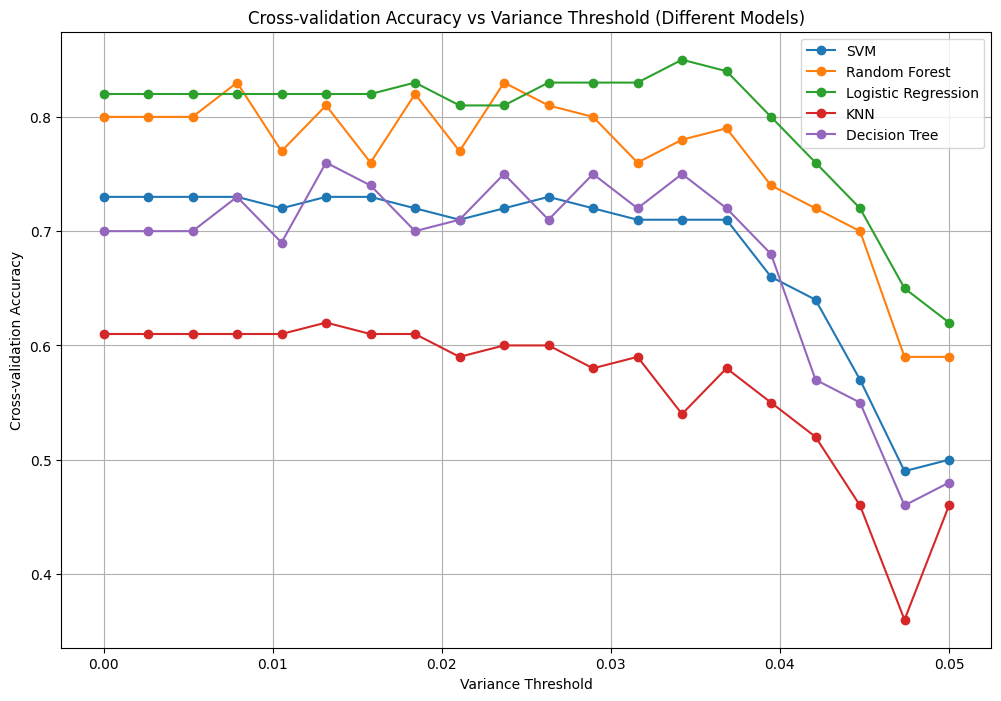

🏆 Best for SVM: Threshold = 0.000, Accuracy = 0.7300
🏆 Best for Random Forest: Threshold = 0.008, Accuracy = 0.8300
🏆 Best for Logistic Regression: Threshold = 0.034, Accuracy = 0.8500
🏆 Best for KNN: Threshold = 0.013, Accuracy = 0.6200
🏆 Best for Decision Tree: Threshold = 0.013, Accuracy = 0.7600


In [67]:




# Define range of thresholds
thresholds = np.linspace(0, 0.05, 20)

# Define models to test
models = {
    'SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Store results
results = {model_name: [] for model_name in models.keys()}

# Loop over thresholds
for threshold in thresholds:
    selector = VarianceThreshold(threshold=threshold)
    try:
        X_selected = selector.fit_transform(X_normalized_df)

        if X_selected.shape[1] == 0:
            # No features left
            for model_name in models.keys():
                results[model_name].append(0)
            continue

        for model_name, model in models.items():
            scores = cross_val_score(model, X_selected, y, cv=10, scoring='accuracy')
            results[model_name].append(scores.mean())

    except Exception as e:
        print(f"Error at threshold {threshold}: {e}")
        for model_name in models.keys():
            results[model_name].append(0)

# Plot results
plt.figure(figsize=(12, 8))
for model_name in models.keys():
    plt.plot(thresholds, results[model_name], marker='o', label=model_name)

plt.title('Cross-validation Accuracy vs Variance Threshold (Different Models)')
plt.xlabel('Variance Threshold')
plt.ylabel('Cross-validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Find and print best results
for model_name in models.keys():
    best_idx = np.argmax(results[model_name])
    print(f"🏆 Best for {model_name}: Threshold = {thresholds[best_idx]:.3f}, Accuracy = {results[model_name][best_idx]:.4f}")


# 4. Model Training

### Model Definition
Define Best Models Based on Feature Selection

In [ ]:
# Store results
final_results = {}


In [42]:
# 1. Create feature selectors based on best thresholds
# Define pipelines for each model
pipelines = {
    'SVM': Pipeline([
        ('var_thresh', VarianceThreshold(threshold=0.000)),
        ('clf', SVC(kernel='linear', C=1, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('var_thresh', VarianceThreshold(threshold=0.008)),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2, random_state=42))
    ]),
    'Logistic Regression': Pipeline([
        ('var_thresh', VarianceThreshold(threshold=0.034)),
        ('clf', LogisticRegression(C=0.01, penalty='l2', solver='liblinear', random_state=42))
    ]),
    'KNN': Pipeline([
        ('var_thresh', VarianceThreshold(threshold=0.013)),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Decision Tree': Pipeline([
        ('var_thresh', VarianceThreshold(threshold=0.013)),
        ('clf', DecisionTreeClassifier(random_state=42))
    ])
}

In [43]:
final_scores = {}

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_normalized_df, y, cv=10)
    final_scores[name] = scores
    print(f"🏁 {name}: Accuracy = {scores.mean():.4f} ± {scores.std():.4f}")

In [46]:
# Important: split(X, y), not just X
for fold, (train_index, val_index) in enumerate(kfold.split(X, y)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    print(f"\n--- Fold {fold+1} ---")
    print("X_train shape:", X_train.shape)
    print("y_train shape:", y_train.shape)
    print("X_val shape:", X_val.shape)
    print("y_val shape:", y_val.shape)


--- Fold 1 ---
X_train shape: (90, 644)
y_train shape: (90,)
X_val shape: (10, 644)
y_val shape: (10,)

--- Fold 2 ---
X_train shape: (90, 644)
y_train shape: (90,)
X_val shape: (10, 644)
y_val shape: (10,)

--- Fold 3 ---
X_train shape: (90, 644)
y_train shape: (90,)
X_val shape: (10, 644)
y_val shape: (10,)

--- Fold 4 ---
X_train shape: (90, 644)
y_train shape: (90,)
X_val shape: (10, 644)
y_val shape: (10,)

--- Fold 5 ---
X_train shape: (90, 644)
y_train shape: (90,)
X_val shape: (10, 644)
y_val shape: (10,)

--- Fold 6 ---
X_train shape: (90, 644)
y_train shape: (90,)
X_val shape: (10, 644)
y_val shape: (10,)

--- Fold 7 ---
X_train shape: (90, 644)
y_train shape: (90,)
X_val shape: (10, 644)
y_val shape: (10,)

--- Fold 8 ---
X_train shape: (90, 644)
y_train shape: (90,)
X_val shape: (10, 644)
y_val shape: (10,)

--- Fold 9 ---
X_train shape: (90, 644)
y_train shape: (90,)
X_val shape: (10, 644)
y_val shape: (10,)

--- Fold 10 ---
X_train shape: (90, 644)
y_train shape: (90,)
X

In [47]:
# Perform cross-validation
logreg_scores = cross_val_score(pipeline_logreg, X_normalized_df, y, cv=kfold, scoring='accuracy')
rf_scores = cross_val_score(pipeline_rf, X_normalized_df, y, cv=kfold, scoring='accuracy')


report:

Mean accuracy across folds

Standard deviation (to check stability)

In [48]:
# Print results
print("=== Logistic Regression Cross-Validation Results ===")
print(f"Accuracy: {logreg_scores.mean():.4f} ± {logreg_scores.std():.4f}")

print("\n=== Random Forest Cross-Validation Results ===")
print(f"Accuracy: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

=== Logistic Regression Cross-Validation Results ===
Accuracy: 0.7800 ± 0.1249

=== Random Forest Cross-Validation Results ===
Accuracy: 0.8000 ± 0.0894


boxplot shows how spread out and stable your fold scores are for each model.
What this shows:
Box ➔ interquartile range (IQR) of the scores.

Whiskers ➔ minimum and maximum (without outliers).

Dots ➔ individual fold accuracies (stripplot).

Higher box = better, narrower box = more stable.





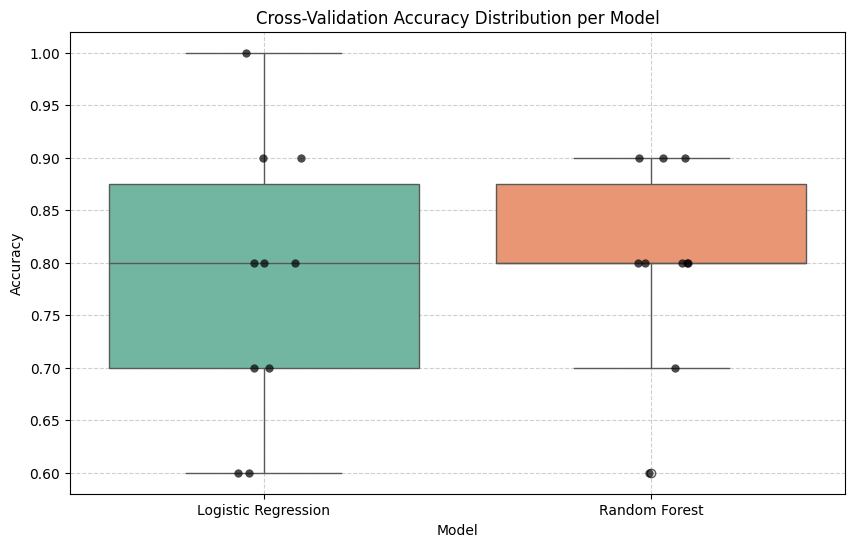

In [49]:
# First, collect the scores
models_scores = {
    'Logistic Regression': logreg_scores,
    'Random Forest': rf_scores
}

# Create a DataFrame for easier plotting
import pandas as pd
scores_df = pd.DataFrame([
    {'Model': model, 'Accuracy': score}
    for model, scores in models_scores.items()
    for score in scores
])

# Now plot the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='Accuracy', data=scores_df, palette="Set2")
sns.stripplot(x='Model', y='Accuracy', data=scores_df,
              color='black', size=6, jitter=True, alpha=0.7)

plt.title('Cross-Validation Accuracy Distribution per Model')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Violin shape ➔ the distribution/density of fold scores.

Box inside ➔ median and quartiles.

Small white dot ➔ the median (50%).

Outliers ➔ points beyond the whiskers.

Wider areas mean more scores are concentrated there.

Narrow = fewer fold results at that score.

Stable models will have tighter violins and boxes.

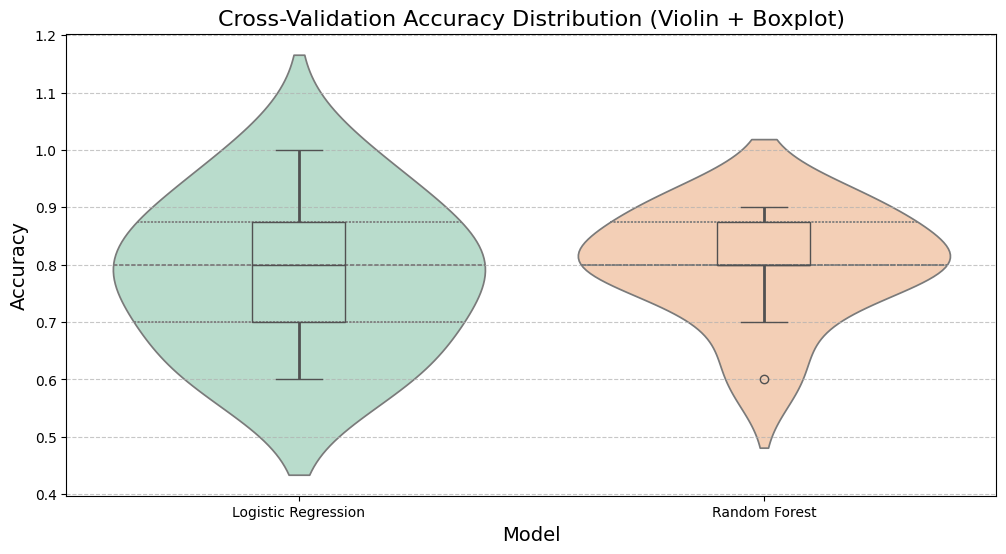

In [50]:



# Collect the scores into a DataFrame
models_scores = {
    'Logistic Regression': logreg_scores,
    'Random Forest': rf_scores
}

scores_df = pd.DataFrame([
    {'Model': model, 'Accuracy': score}
    for model, scores in models_scores.items()
    for score in scores
])

# Plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Model', y='Accuracy', data=scores_df, inner='quartile', palette="Pastel2")
sns.boxplot(x='Model', y='Accuracy', data=scores_df, width=0.2, showcaps=True, boxprops={'facecolor':'None'}, showfliers=True, whiskerprops={'linewidth':2})

plt.title('Cross-Validation Accuracy Distribution (Violin + Boxplot)', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Train models


In [51]:
pipeline_logreg.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('selector', VarianceThreshold(threshold=0.011)),
                ('model', RandomForestClassifier(random_state=42))])

### # Evaluate models



In [52]:
y_pred_logreg = pipeline_logreg.predict(X_val)
y_pred_rf = pipeline_rf.predict(X_val)

In [53]:
print("=== Logistic Regression Performance ===")
print("Accuracy:", accuracy_score(y_val, y_pred_logreg))
print(classification_report(y_val, y_pred_logreg))

print("\n=== Random Forest Performance ===")
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

=== Logistic Regression Performance ===
Accuracy: 0.9
              precision    recall  f1-score   support

         DCM       1.00      1.00      1.00         2
         HCM       1.00      0.50      0.67         2
        MINF       1.00      1.00      1.00         2
         NOR       0.67      1.00      0.80         2
          RV       1.00      1.00      1.00         2

    accuracy                           0.90        10
   macro avg       0.93      0.90      0.89        10
weighted avg       0.93      0.90      0.89        10


=== Random Forest Performance ===
Accuracy: 0.9
              precision    recall  f1-score   support

         DCM       1.00      1.00      1.00         2
         HCM       1.00      0.50      0.67         2
        MINF       1.00      1.00      1.00         2
         NOR       0.67      1.00      0.80         2
          RV       1.00      1.00      1.00         2

    accuracy                           0.90        10
   macro avg       0.93     

###Fine-Tune with GridSearchCV

In [54]:


# parameter grids for different models:
param_grids = {

    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10]
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "penalty": ['l2'],
        "solver": ['lbfgs', 'liblinear']
    }

}


In [57]:
# Retrieve the parameter grid for the selected model
best_param_grid = param_grids.get("Random Forest")

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=models["Random Forest"],
    param_grid=best_param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit on all data
grid_search.fit(X, y)

# Best hyperparameters and best score
print(f"🏆 Best Hyperparameters for 'Random Forest': {grid_search.best_params_}")
print(f"✅ Best Accuracy after tuning: {grid_search.best_score_:.4f}")

# Final tuned model
best_tuned_model = grid_search.best_estimator_

Fitting 10 folds for each of 27 candidates, totalling 270 fits
🏆 Best Hyperparameters for 'Random Forest': {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
✅ Best Accuracy after tuning: 0.8100


In [58]:
# Retrieve the parameter grid for the selected model
best_param_grid = param_grids.get("Logistic Regression")

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=models["Logistic Regression"],
    param_grid=best_param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit on all data
grid_search.fit(X, y)

# Best hyperparameters and best score
print(f"🏆 Best Hyperparameters for 'Random Forest': {grid_search.best_params_}")
print(f"✅ Best Accuracy after tuning: {grid_search.best_score_:.4f}")

# Final tuned model
best_tuned_model = grid_search.best_estimator_

Fitting 10 folds for each of 8 candidates, totalling 80 fits
🏆 Best Hyperparameters for 'Random Forest': {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
✅ Best Accuracy after tuning: 0.7600


### Feature Importance plots for this tuned Random Forest 🎯





In [59]:
importances = final_rf_model.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = feature_names[indices]
sorted_importances = importances[indices]

# Plot
plt.figure(figsize=(12, 8))
plt.title('Feature Importances - Tuned Random Forest', fontsize=16)
plt.bar(range(20), sorted_importances[:20], align='center', color='royalblue')
plt.xticks(range(20), sorted_features[:20], rotation=90)
plt.xlabel('Feature', fontsize=14)
plt.ylabel('Importance', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

NameError: name 'final_rf_model' is not defined

###Confusion matrix visualization

###ROC-AUC Curve for a deeper evaluation?

# Classification Models

In [ ]:
# Cargamos las librerías
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, log_loss, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [ ]:
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    balanced_accuracy_score, log_loss
)

In [ ]:
# Seleccionamos las variables predictoras y la variable objetivo
# Dividimos el conjunto de entrenamiento en train y val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=2)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_val = sc_X.transform(X_val)

### K-NN

In [ ]:
classifier = KNeighborsClassifier(n_neighbors = 5, metric = "minkowski", p = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred  = classifier.predict(X_val)

In [ ]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         DCM       0.67      0.67      0.67         6
         HCM       0.50      0.25      0.33         4
        MINF       0.25      0.50      0.33         4
         NOR       0.40      0.29      0.33         7
          RV       1.00      1.00      1.00         3

    accuracy                           0.50        24
   macro avg       0.56      0.54      0.53        24
weighted avg       0.53      0.50      0.50        24



In [ ]:
confusion_matrix(y_val, y_pred)

array([[4, 0, 2, 0, 0],
       [0, 1, 1, 2, 0],
       [1, 0, 2, 1, 0],
       [1, 1, 3, 2, 0],
       [0, 0, 0, 0, 3]])

In [ ]:
conf=pd.DataFrame(
    confusion_matrix(y_val, y_pred),
    columns=['DCM', 'HCM','MINF','NOR','RV'],
    index  =['DCM', 'HCM','MINF','NOR','RV']
)
print(conf)

      DCM  HCM  MINF  NOR  RV
DCM     4    0     2    0   0
HCM     0    1     1    2   0
MINF    1    0     2    1   0
NOR     1    1     3    2   0
RV      0    0     0    0   3


In [ ]:
accuracy_score(y_val, y_pred)

0.5

In [ ]:
# For class predictions (imbalanced data)
bal_acc = balanced_accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='weighted')

### NB

In [ ]:
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred  = classifier.predict(X_val)

In [ ]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         DCM       0.00      0.00      0.00         6
         HCM       0.00      0.00      0.00         4
        MINF       0.00      0.00      0.00         4
         NOR       0.50      0.29      0.36         7
          RV       0.30      1.00      0.46         3

    accuracy                           0.21        24
   macro avg       0.16      0.26      0.17        24
weighted avg       0.18      0.21      0.16        24



In [ ]:
confusion_matrix(y_val, y_pred)

array([[0, 1, 4, 0, 1],
       [0, 0, 1, 2, 1],
       [1, 1, 0, 0, 2],
       [0, 2, 0, 2, 3],
       [0, 0, 0, 0, 3]])

In [ ]:
conf=pd.DataFrame(
    confusion_matrix(y_val, y_pred),
    columns=['DCM', 'HCM','MINF','NOR','RV'],
    index  =['DCM', 'HCM','MINF','NOR','RV']
)
print(conf)

      DCM  HCM  MINF  NOR  RV
DCM     0    1     4    0   1
HCM     0    0     1    2   1
MINF    1    1     0    0   2
NOR     0    2     0    2   3
RV      0    0     0    0   3


In [ ]:
accuracy_score(y_val, y_pred)

0.20833333333333334

### SVM

In [ ]:
classifier = SVC(C=10, gamma = 0.08, kernel = 'rbf')
classifier.fit(X_train, y_train)

SVC(C=10, gamma=0.08)

In [ ]:
y_pred  = classifier.predict(X_val)

In [ ]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         DCM       0.00      0.00      0.00         6
         HCM       0.00      0.00      0.00         4
        MINF       0.67      0.50      0.57         4
         NOR       0.00      0.00      0.00         7
          RV       0.14      1.00      0.25         3

    accuracy                           0.21        24
   macro avg       0.16      0.30      0.16        24
weighted avg       0.13      0.21      0.13        24



In [ ]:
confusion_matrix(y_val, y_pred)

array([[0, 0, 1, 0, 5],
       [0, 0, 0, 0, 4],
       [0, 0, 2, 0, 2],
       [0, 0, 0, 0, 7],
       [0, 0, 0, 0, 3]])

In [ ]:
conf=pd.DataFrame(
    confusion_matrix(y_val, y_pred),
    columns=['DCM', 'HCM','MINF','NOR','RV'],
    index  =['DCM', 'HCM','MINF','NOR','RV']
)
print(conf)

      DCM  HCM  MINF  NOR  RV
DCM     0    0     1    0   5
HCM     0    0     0    0   4
MINF    0    0     2    0   2
NOR     0    0     0    0   7
RV      0    0     0    0   3


In [ ]:
accuracy_score(y_val, y_pred)

0.20833333333333334

### MEJOR MODELO

# 4. Model Training

### Train Models with K-Fold and Pipelines
